# Figure 3 — version harmonisée

Toutes les figures sont en `figsize=(8,6)`. Chaque cellule est autonome (imports + chargement des données + tracé) tout en réutilisant la même logique de couleurs (`color_list`) d'une cellule à l'autre lorsque cela a du sens physiquement.

# 3.A : Few trajectories + Mean + Theory (Random landscape)

Trajectoires individuelles, moyenne de simulation, et fits optionnels du régime initial ($v_{init}$) et du régime final ($t^{w_f}$).

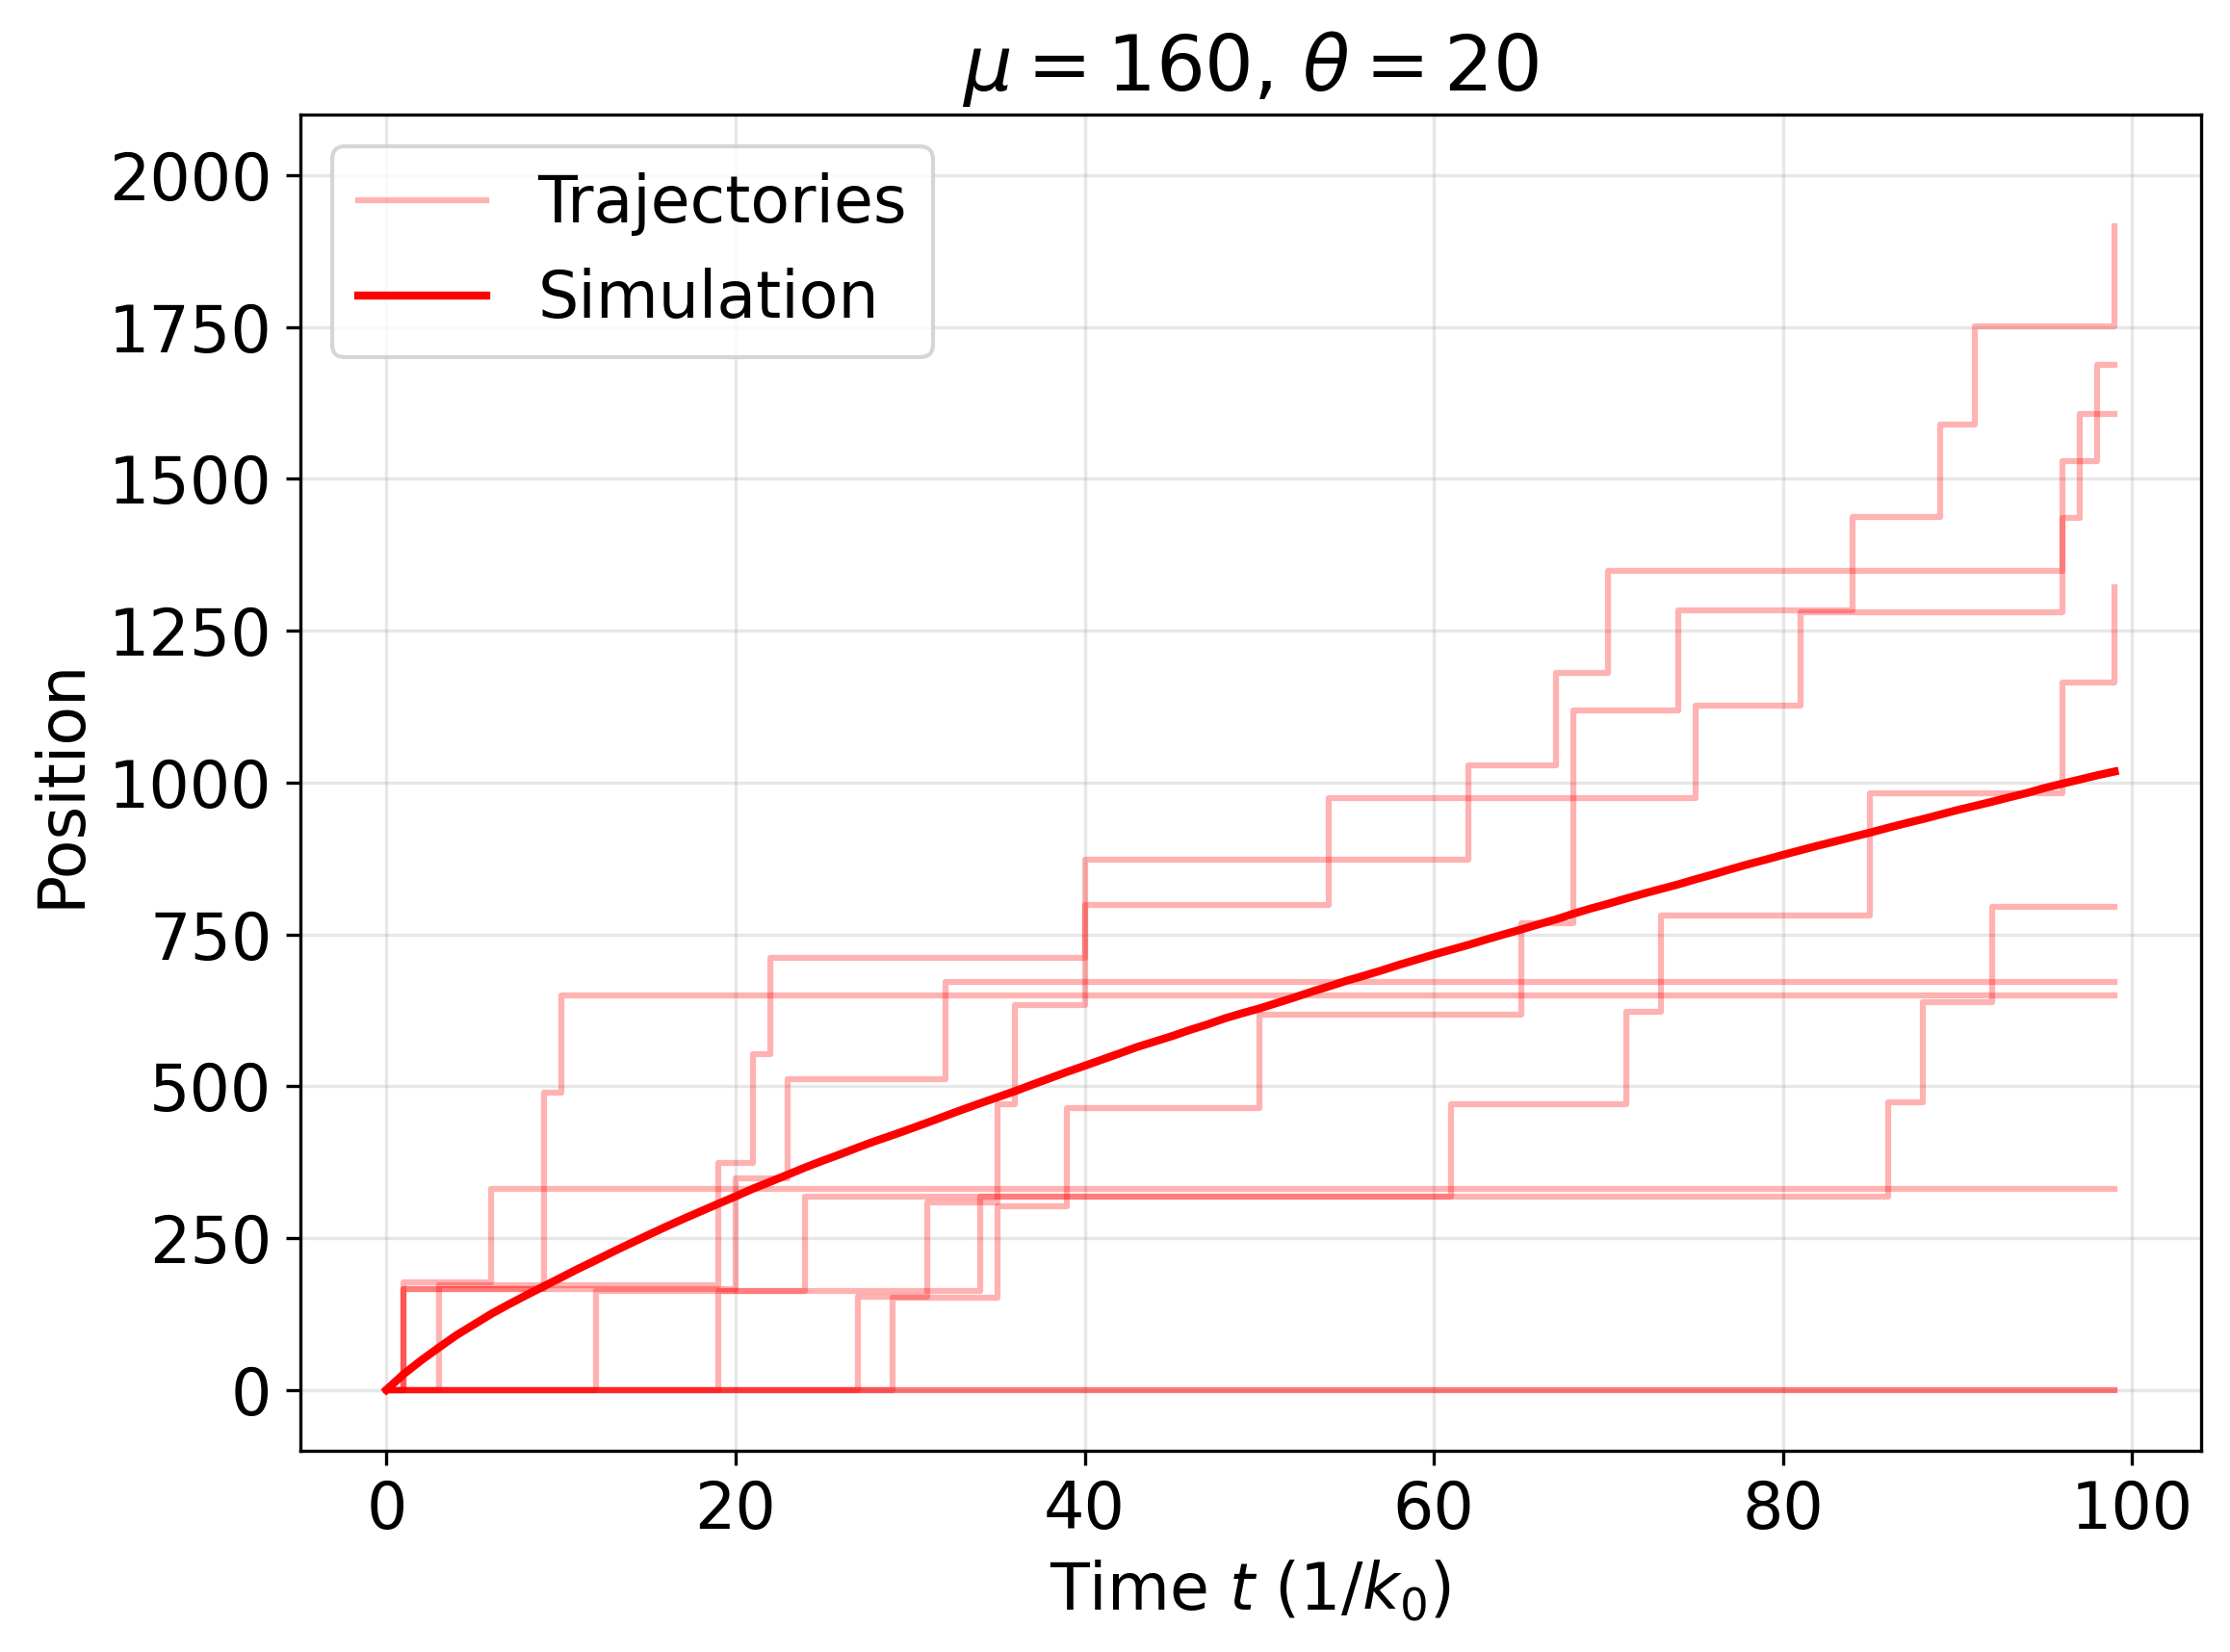

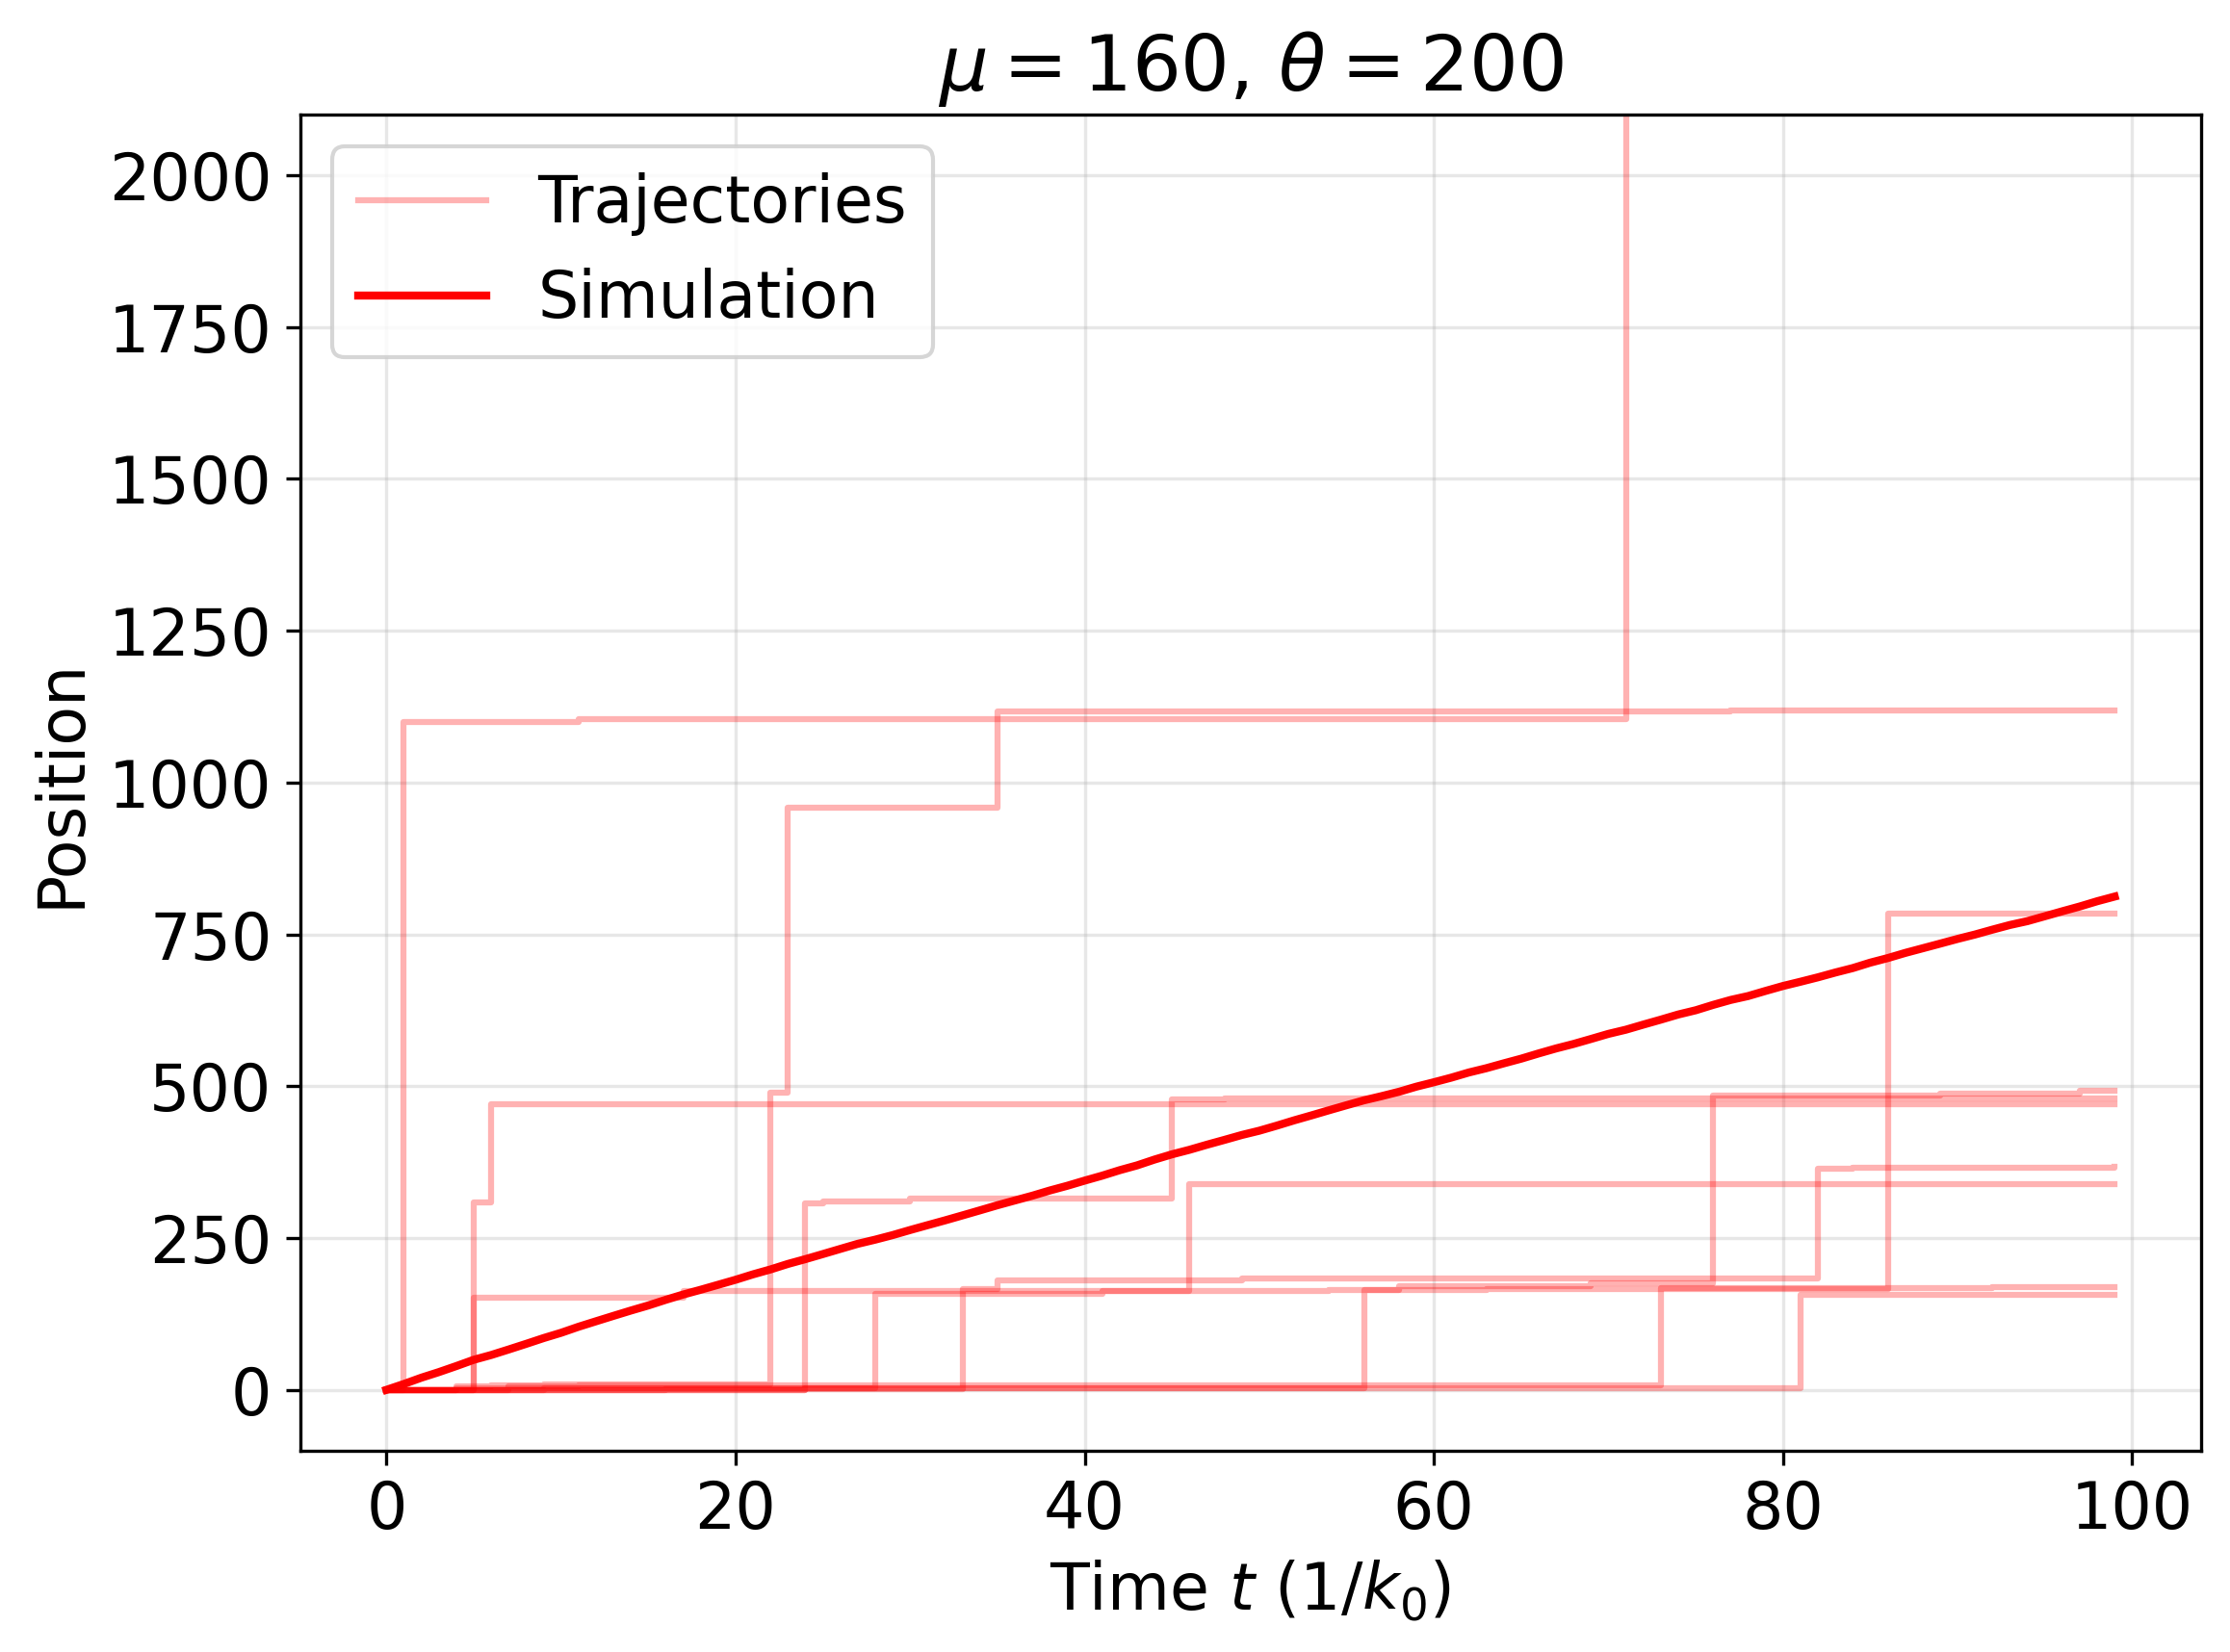

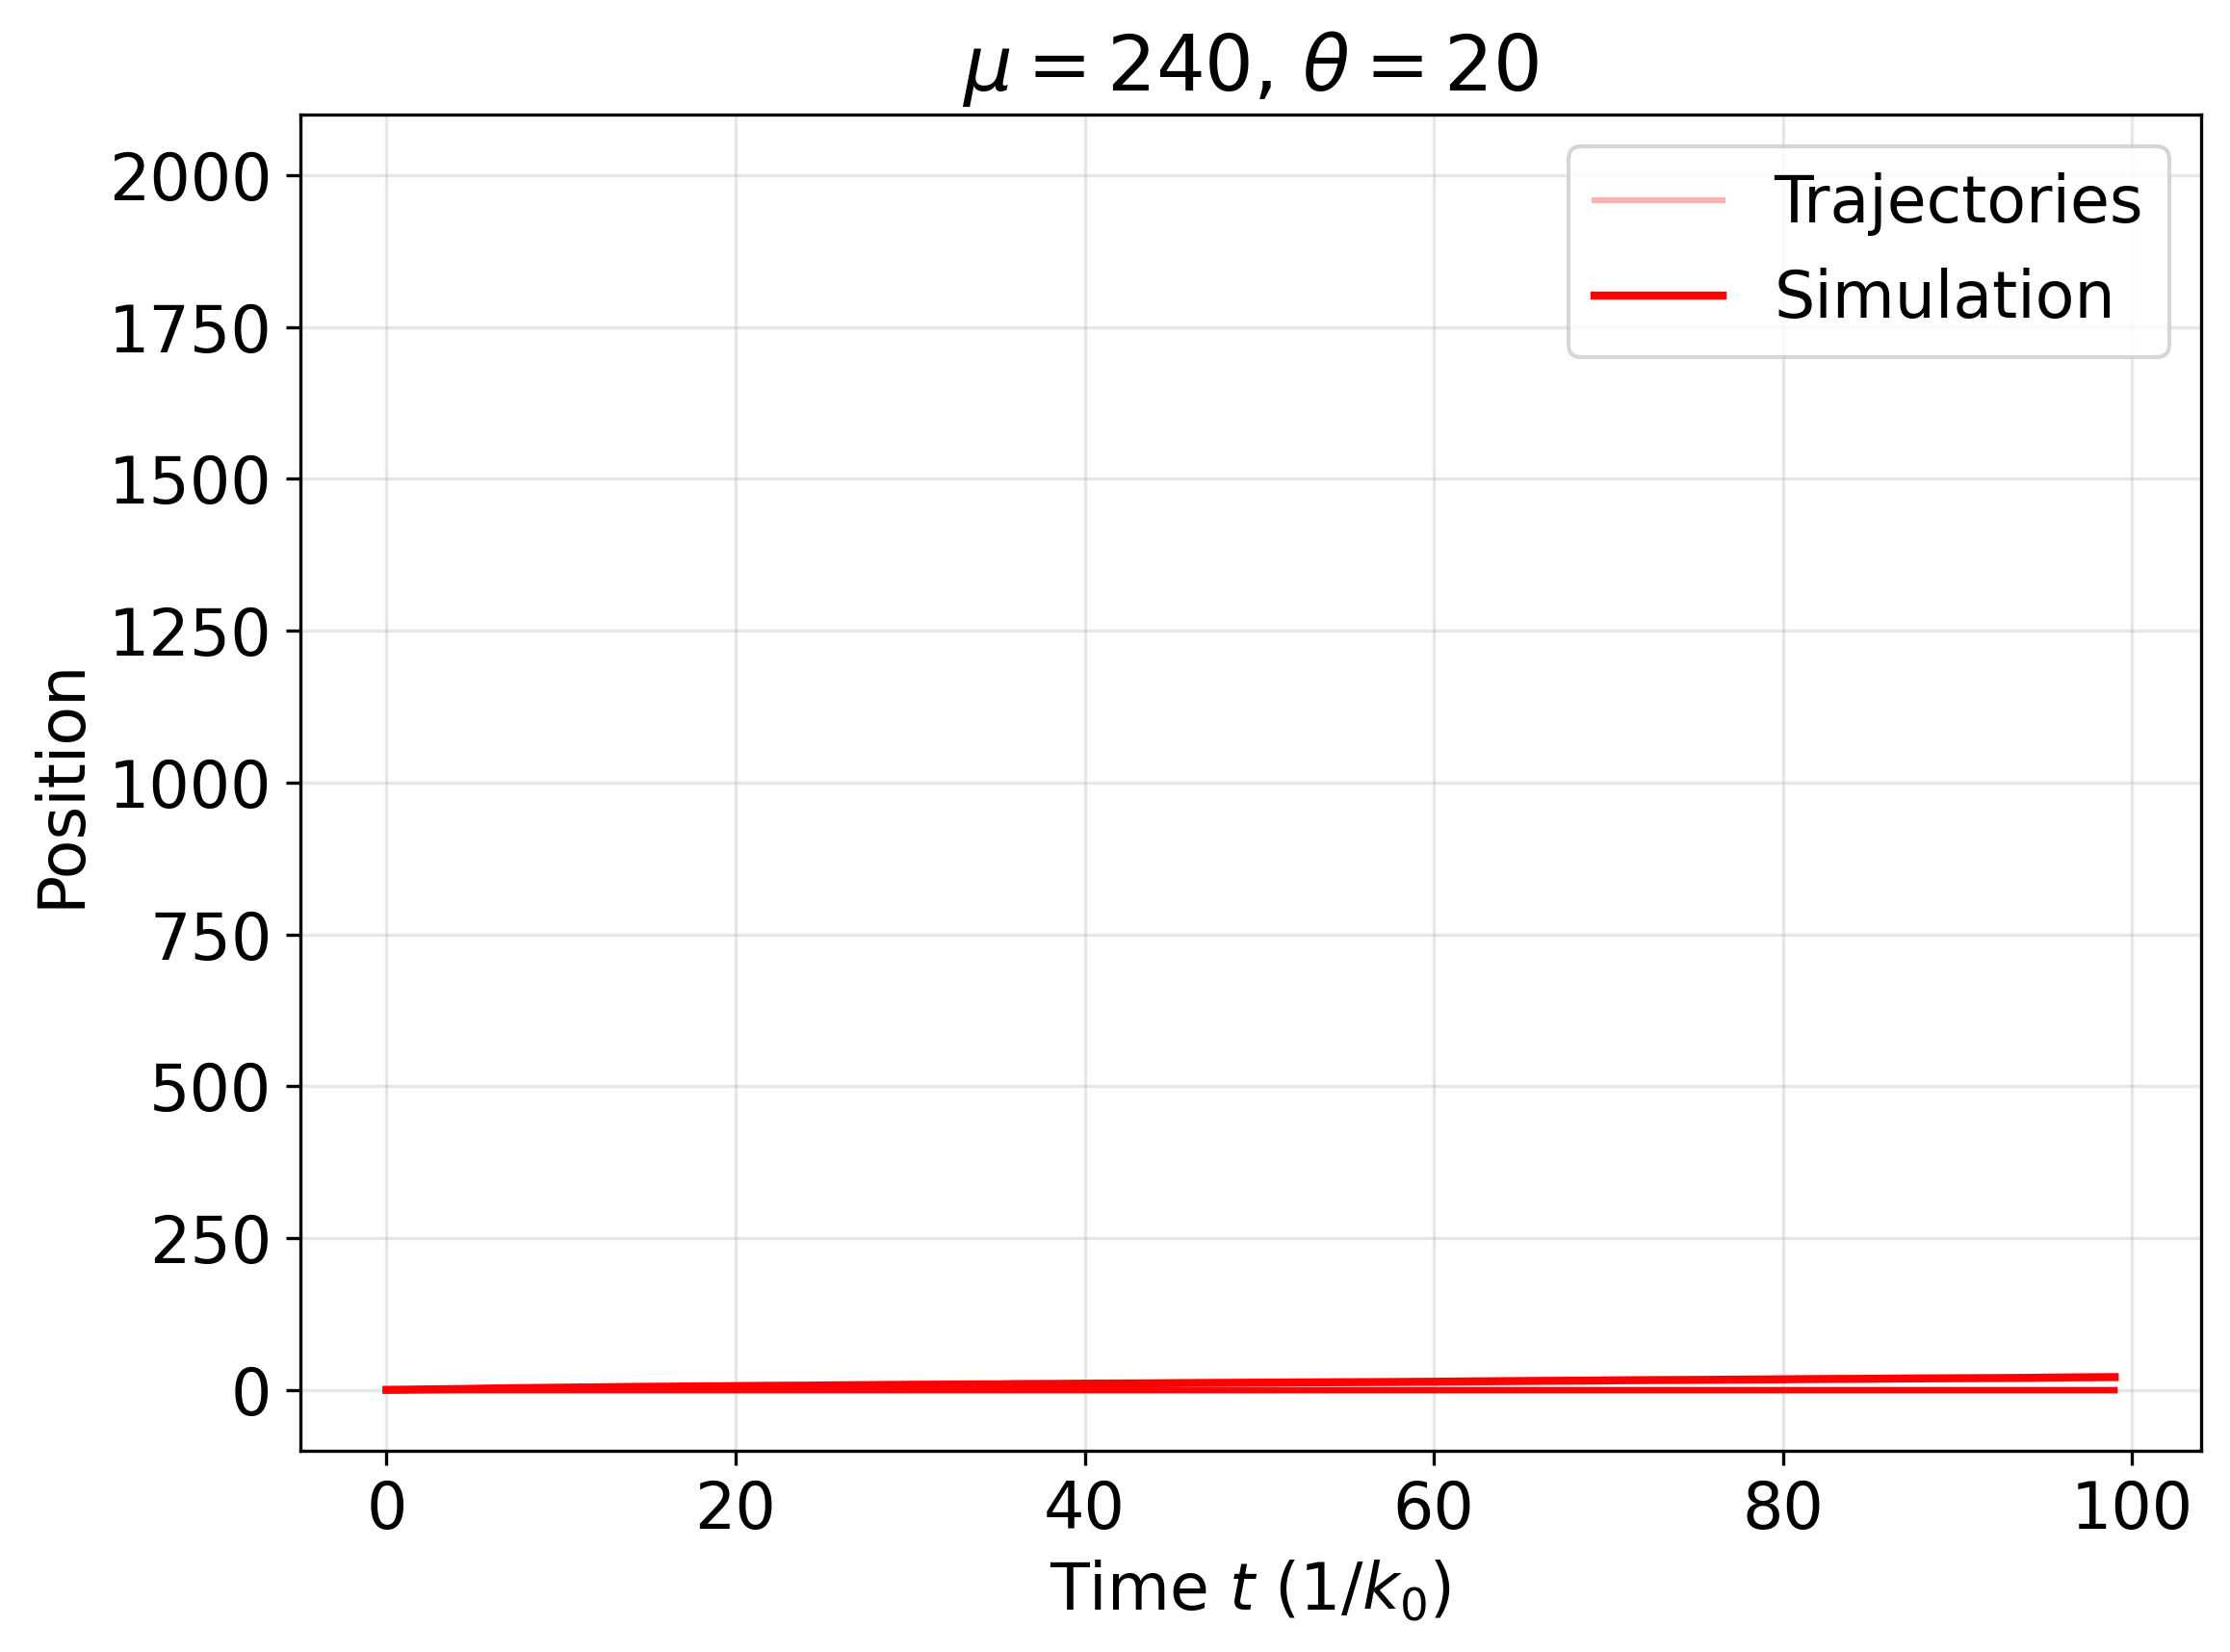

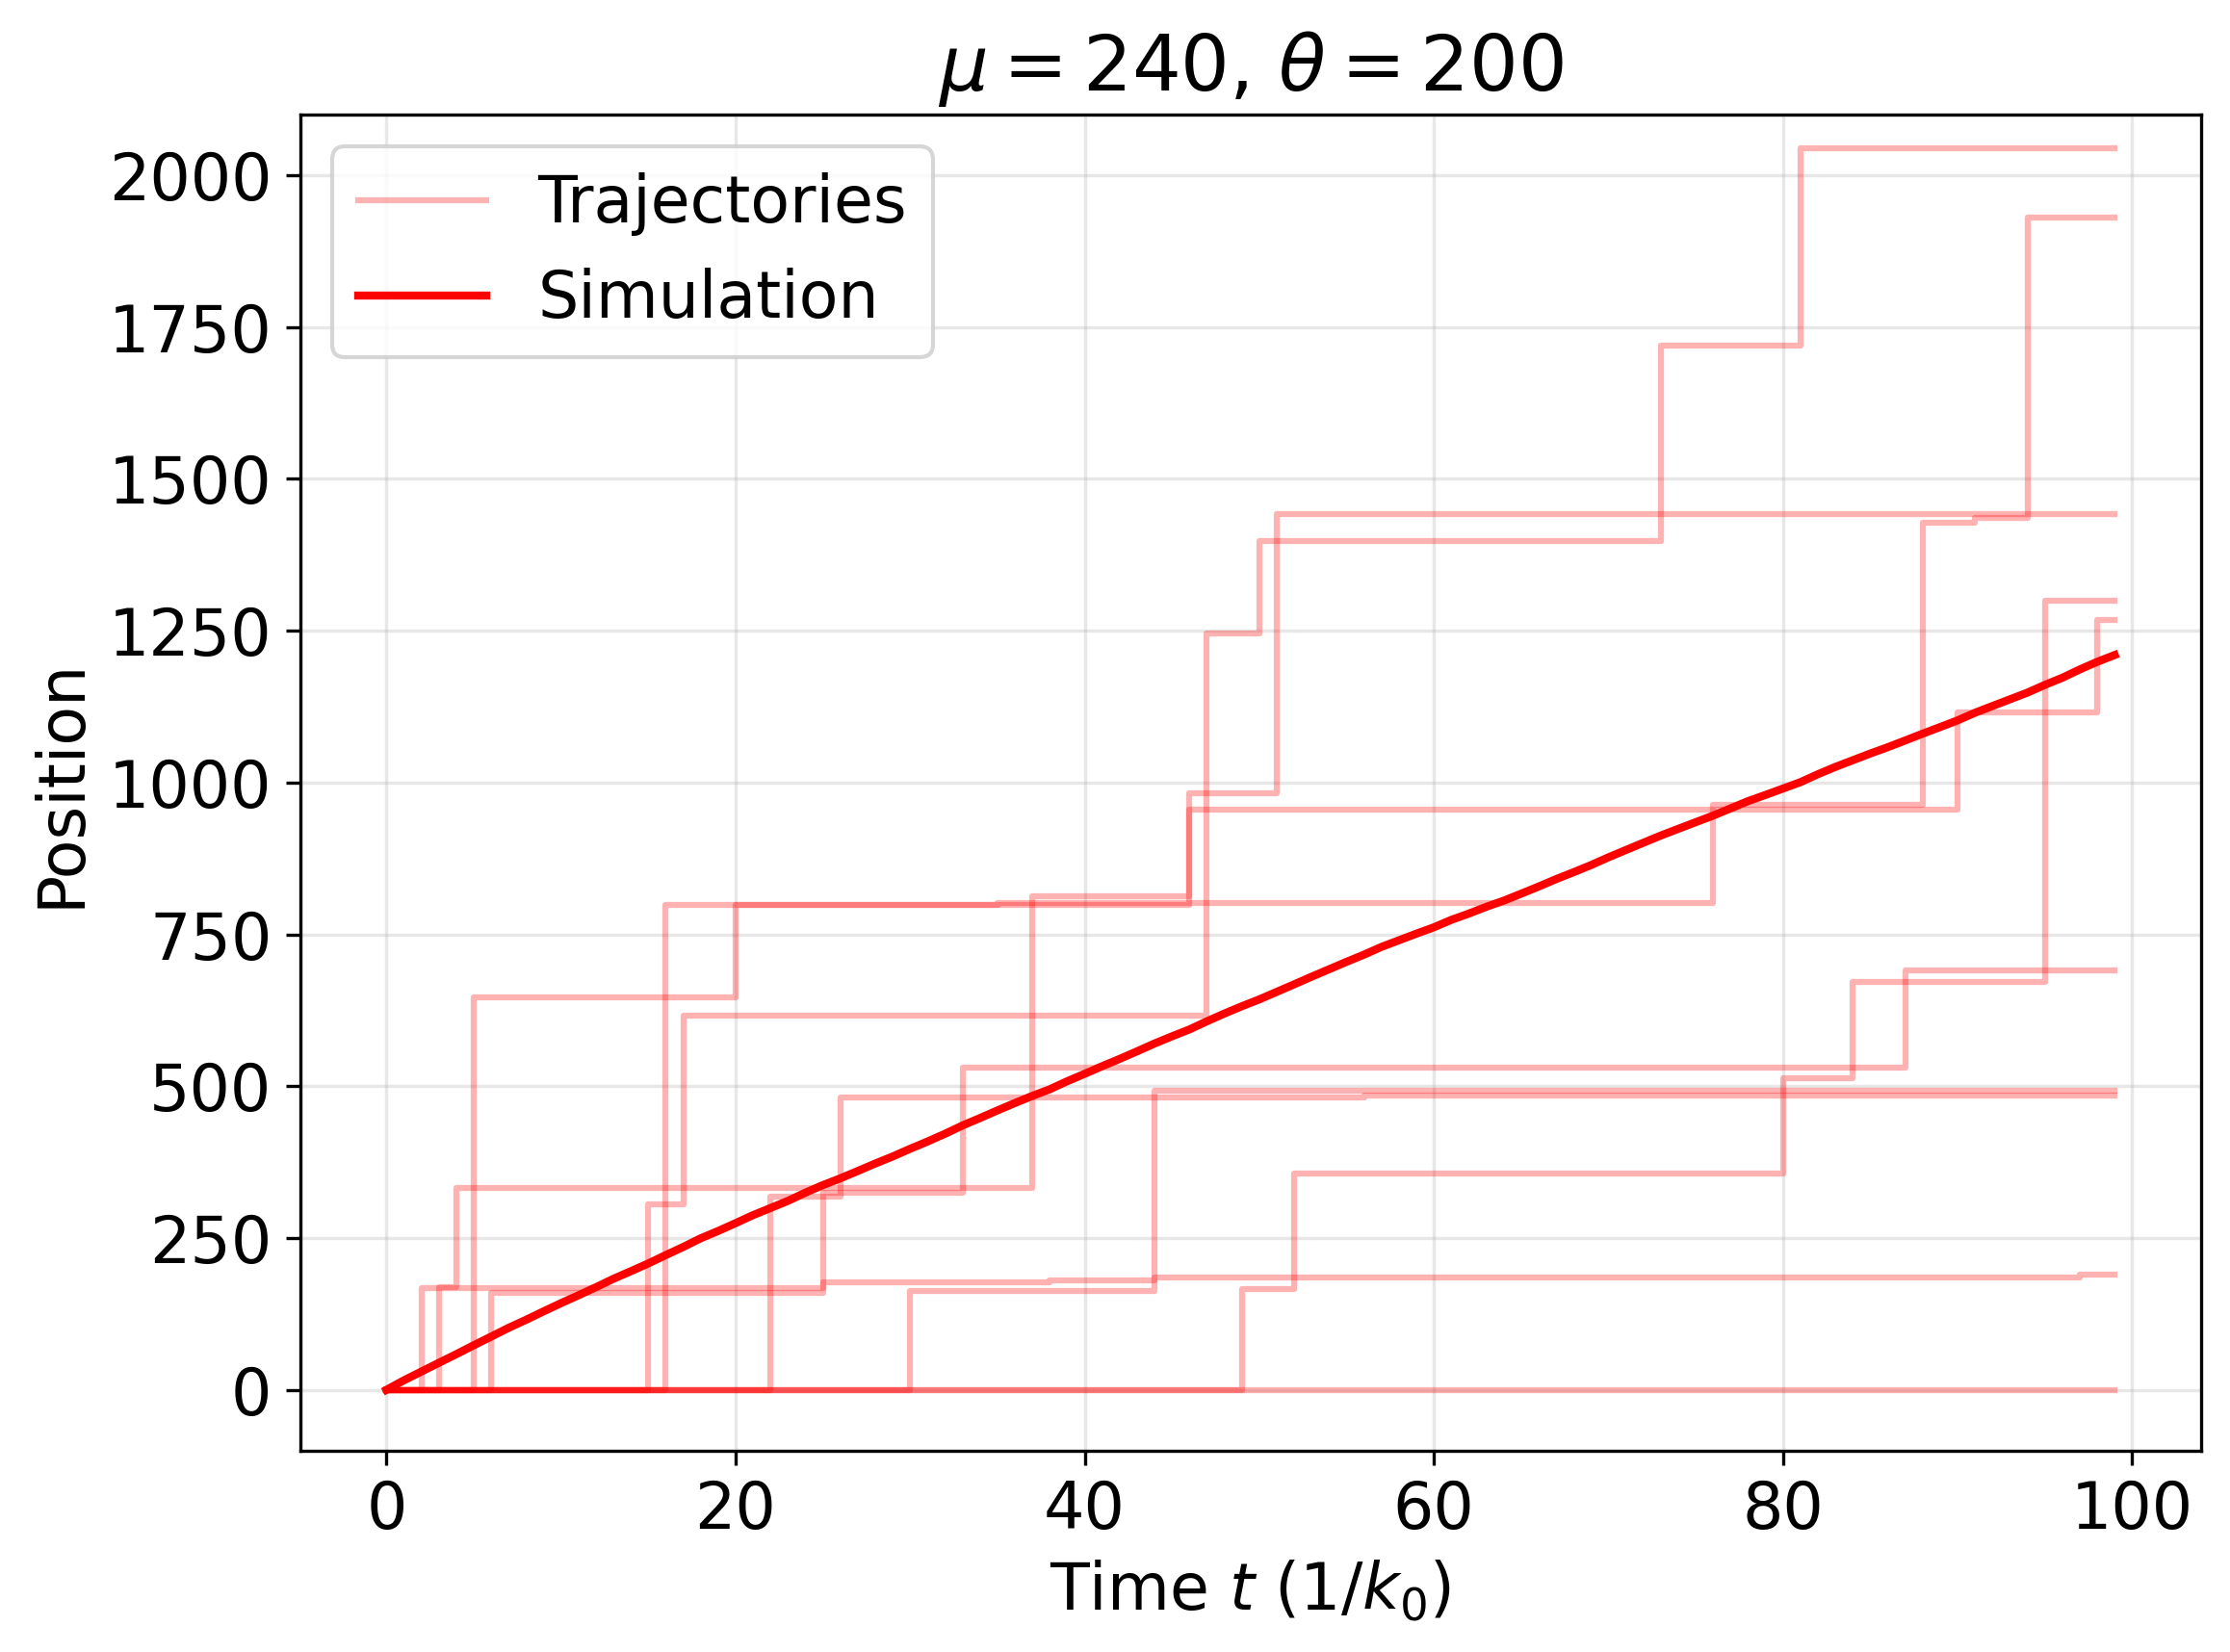

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 16

# ── Options ──────────────────────────────────────────────────────────────────
fit = False
n_fit_init = 5
n_fit_final = 5

# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig3__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

df_one = df_all.filter(pl.col("land") == "random")

# ── Couples uniques (mu, theta) ──────────────────────────────────────────────
pairs = (
    df_one.select(["mu", "theta"])
    .unique()
    .sort(["mu", "theta"])
    .to_numpy()
)

# ── Couleurs (une couleur par couple (mu, theta), cohérent sur tout le notebook) ──
color_list = ["red"] * len(pairs)  # une seule courbe par figure -> rouge par défaut

# ── Loop & Plot ──────────────────────────────────────────────────────────────
for idx, (mu_val, theta_val) in enumerate(pairs):

    df_theta = df_one.filter(
        (pl.col("mu") == mu_val) &
        (pl.col("theta") == theta_val)
    )

    if df_theta.height == 0:
        continue

    # --- Extraction --- #
    trajs = df_theta["results"][0]
    mean_traj = np.asarray(df_theta["results_mean"][0])
    times = np.asarray(df_theta["times"][0])

    v_mean_th = df_theta["v_mean_th"][0]
    mu = df_theta["mu"][0]

    color = color_list[idx]

    # --- Figure --- #
    plt.figure(figsize=(8, 6), dpi=300)

    # Trajectoires individuelles
    n_traj = min(10, len(trajs))
    for i in range(n_traj):
        plt.plot(
            trajs[i],
            drawstyle="steps-post",
            color=color,
            alpha=0.3,
            label="Trajectories" if i == 0 else None,
        )

    # Moyenne simulation
    plt.plot(
        times,
        mean_traj,
        color=color,
        lw=2,
        label="Simulation",
    )

    # --- Fits --- #
    if fit:

        # ==========================================
        # Fit initial : x(t) = v_init * t
        # ==========================================
        if len(times) >= n_fit_init:

            t_init = times[:n_fit_init]
            x_init = mean_traj[:n_fit_init]

            mask = t_init > 0

            if np.sum(mask) >= 2:

                t_fit = t_init[mask]
                x_fit = x_init[mask]

                # Fit forcé passant par l'origine
                v_init = np.sum(t_fit * x_fit) / np.sum(t_fit**2)

                x_init_fit = v_init * t_fit

                plt.plot(
                    t_fit,
                    x_init_fit,
                    color="black",
                    ls="--",
                    lw=2,
                    # label=rf"$v_{{\rm init}}={v_init:.3g}$",
                )

                idx_txt = len(t_fit) // 2

                x_offset = 0.025 * (plt.xlim()[1] - plt.xlim()[0])
                y_offset = 0.10 * (plt.ylim()[1] - plt.ylim()[0])

                plt.text(
                    t_fit[idx_txt] + x_offset,
                    x_init_fit[idx_txt] + y_offset,
                    rf"$x(t)=v_{{\rm init}}\,t$",
                    color="black",
                    fontsize=plt.rcParams["font.size"],
                    ha="center",
                )

        # ==========================================
        # Fit final : x(t) = C_f * t^{w_f}
        # ==========================================
        if len(times) >= n_fit_final:

            t_end = times[-n_fit_final:]
            x_end = mean_traj[-n_fit_final:]

            mask = (t_end > 0) & (x_end > 0)

            if np.sum(mask) >= 2:

                log_t = np.log(t_end[mask])
                log_x = np.log(x_end[mask])

                wf, log_Cf = np.polyfit(log_t, log_x, 1)
                Cf = np.exp(log_Cf)

                x_end_fit = Cf * t_end**wf

                plt.plot(
                    t_end,
                    x_end_fit,
                    color="black",
                    ls="--",
                    lw=2,
                    # label=rf"$C_f={Cf:.3g},\,w_f={wf:.3g}$",
                )

                idx_txt = len(t_end) // 2

                x_offset = 0.05 * (plt.xlim()[1] - plt.xlim()[0])
                y_offset = 0.05 * (plt.ylim()[1] - plt.ylim()[0])

                plt.text(
                    t_end[idx_txt] - x_offset,
                    x_end_fit[idx_txt] + y_offset,
                    rf"$x(t)=C_f\,t^{{w_f}}$",
                    color="black",
                    fontsize=plt.rcParams["font.size"],
                    ha="center",
                )

    # --- Mise en forme --- #
    plt.ylim([-100, 2100])
    plt.title(rf"$\mu={mu}$, $\theta={theta_val}$")
    plt.xlabel(r"Time $t$ ($1/k_0$)")
    plt.ylabel("Position")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 3.B : Distribution des vitesses (Random landscape)

/tmp/ipykernel_19209/4006992072.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


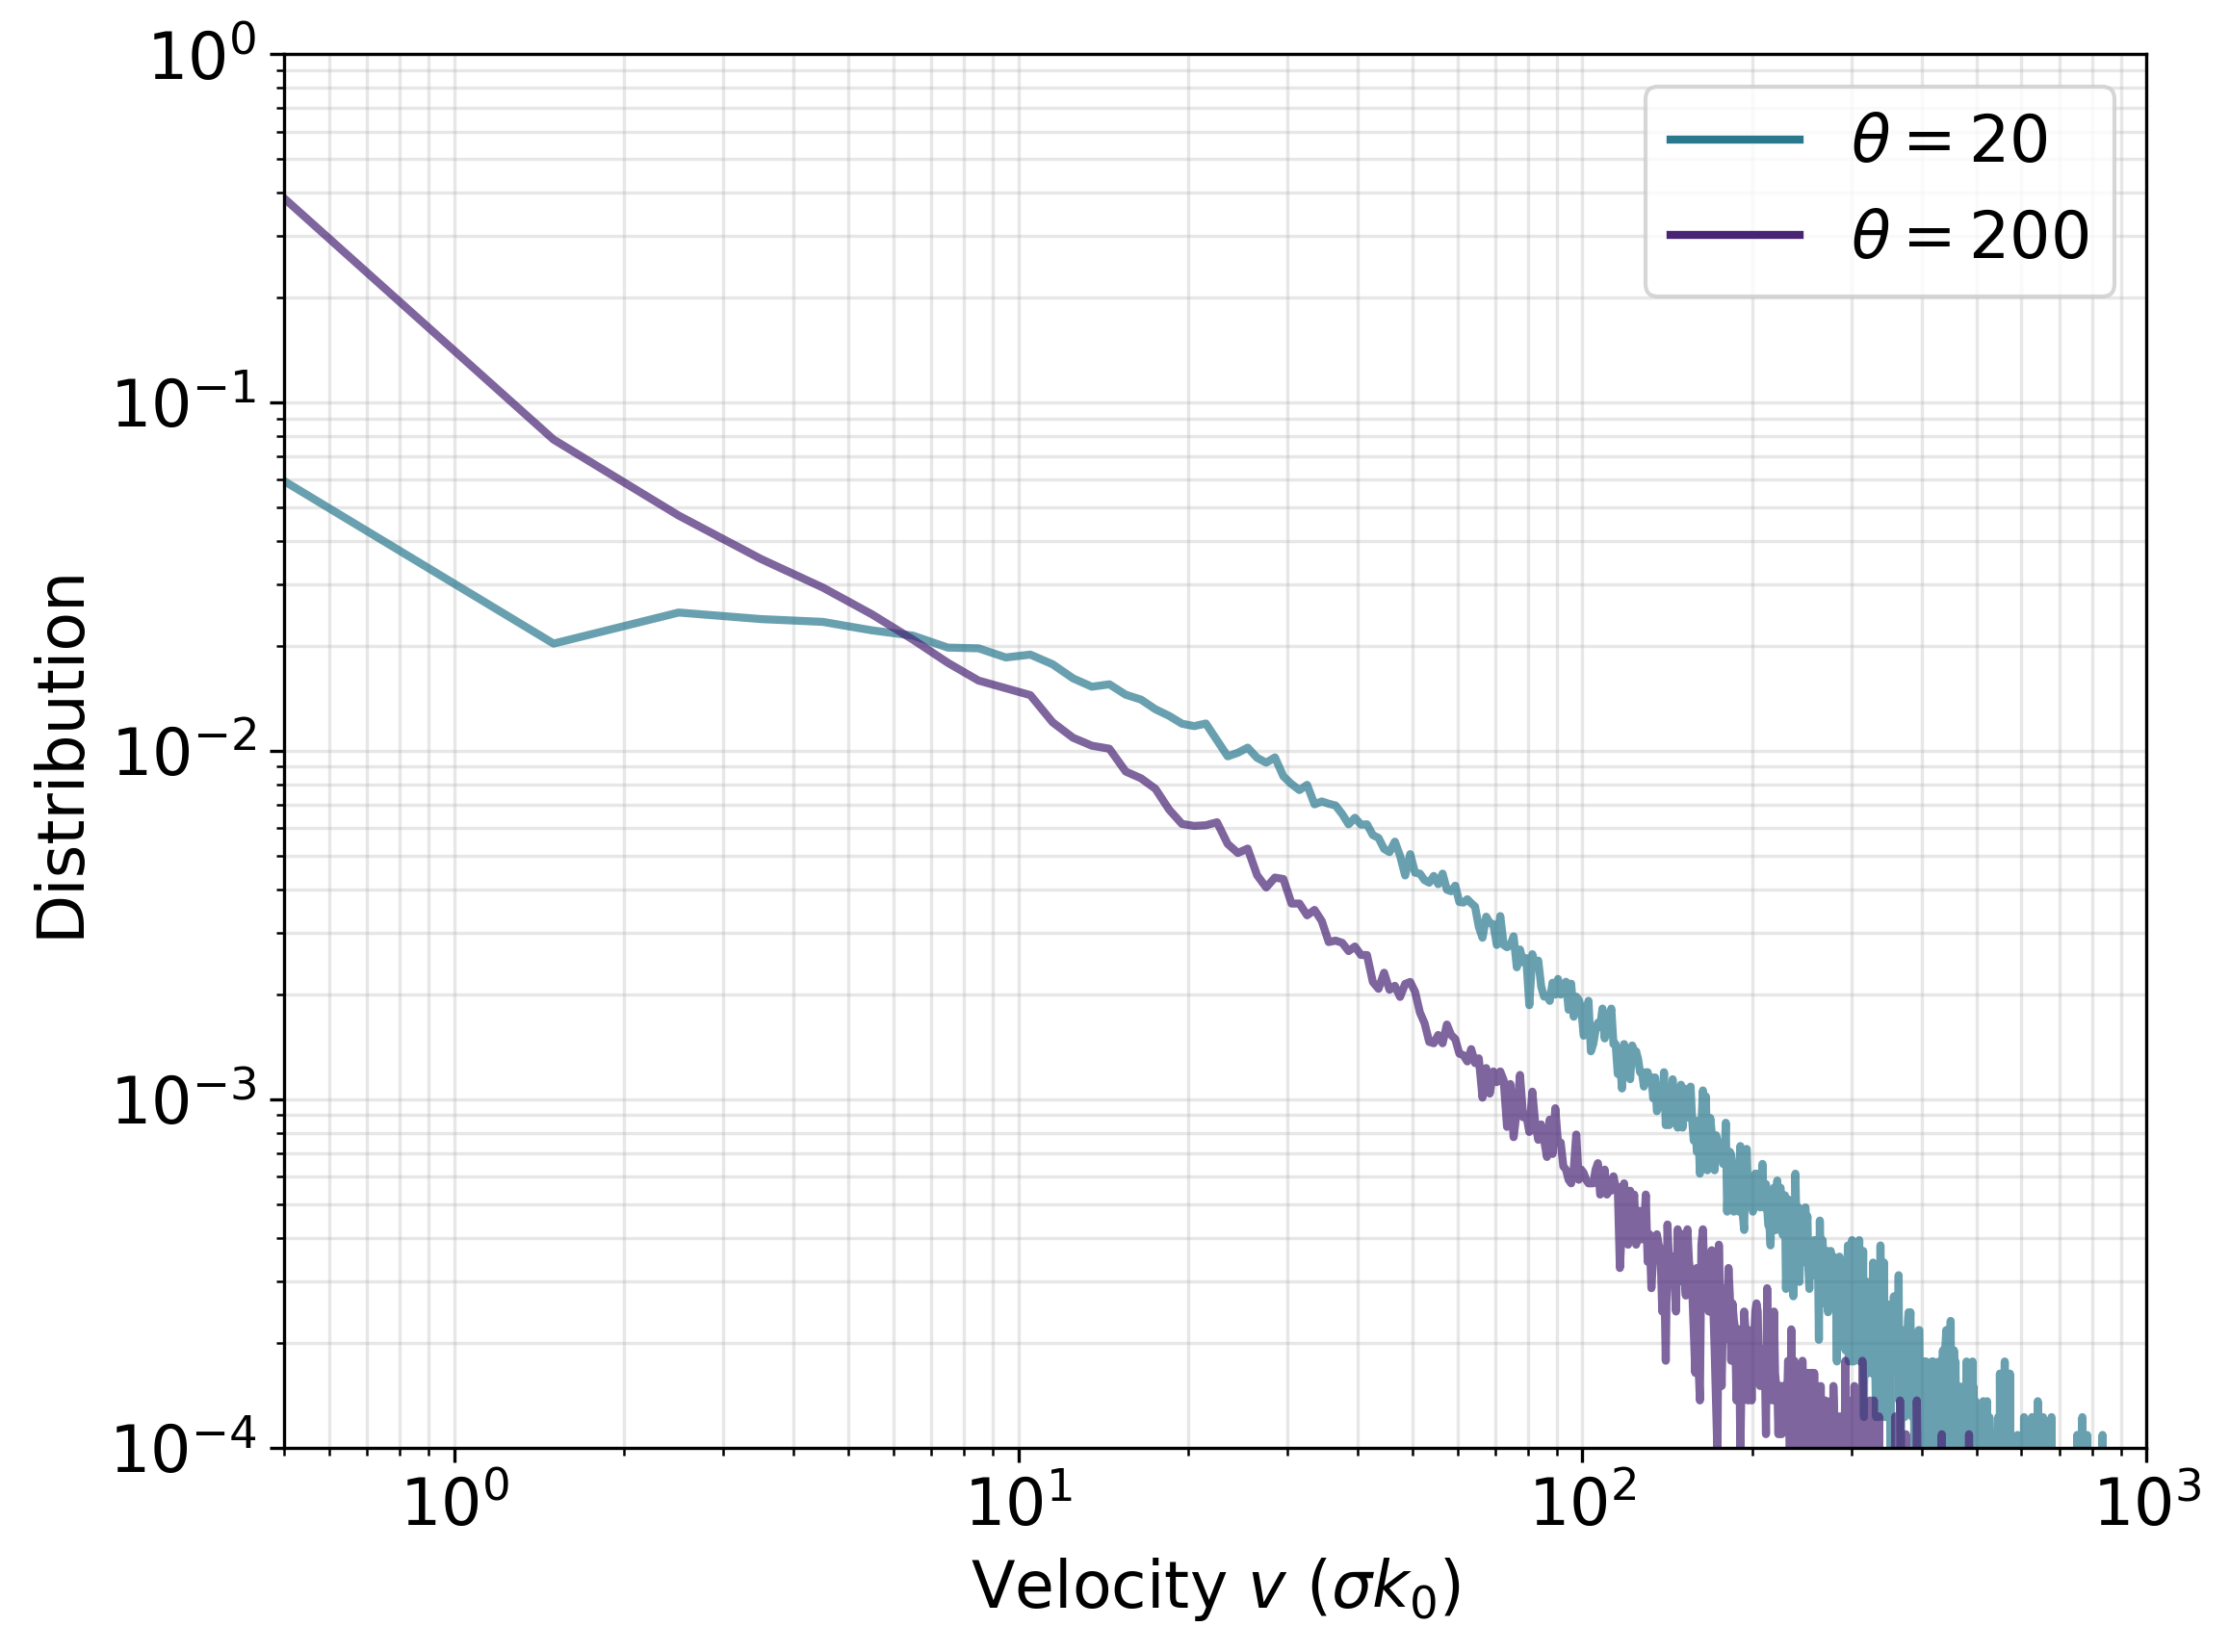

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

plt.rcParams["font.size"] = 16

# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig3__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

# ── Theta values étudiés ─────────────────────────────────────────────────────
thetas = np.unique(df_all["theta"].to_numpy())

# ── Théorie (référence homogène, non utilisée ici car landscape random) ─────
def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)

# ── Couleurs (une couleur par theta, même style que 2.B) ────────────────────
cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)  # ajuste l'intervalle si besoin
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()

# ── Figure ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6), dpi=300)

for idx, theta_val in enumerate(thetas[0:3]):

    df_theta = df_all.filter(pl.col("theta") == theta_val)
    mu = df_theta["mu"][0]
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()
    v_mean = df_theta["v_mean"].to_numpy()

    # Simulation (avec label couleur)
    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[idx],
        ls="-",
        lw=2,
        alpha=0.70,
        label=f"(μ,θ)=({mu},{theta_val})"
    )

    # NB : pas de courbe théorique homogène tracée ici (landscape random,
    # la théorie th_instantaneous_speeds ne s'applique pas directement).

# ── Légendes ─────────────────────────────────────────────────────────────────
ax = plt.gca()

theta_labels = [r"$\theta={}$".format(t) for t in thetas]
color_legend = [Line2D([0], [0], color=color_list[i], lw=2, label=theta_labels[i])
                for i in range(len(thetas))]

ax.legend(handles=color_legend, loc="upper right", frameon=True)

plt.xlabel(r'Velocity $v$ ($\sigma k_0$)')
plt.ylabel("Distribution")
plt.xlim([5e-1, 1e3])
plt.ylim([1e-4, 1e0])
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


# 3.C : $w_f$ en fonction de θ (coupe à µ fixé)

shape: (20, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 5   ┆ 0     ┆ periodic │
│ 150 ┆ 10  ┆ 0     ┆ periodic │
│ 150 ┆ 15  ┆ 0     ┆ periodic │
│ 150 ┆ 20  ┆ 0     ┆ periodic │
│ 150 ┆ 25  ┆ 0     ┆ periodic │
│ …   ┆ …   ┆ …     ┆ …        │
│ 150 ┆ 150 ┆ 0     ┆ random   │
│ 150 ┆ 10  ┆ 5     ┆ random   │
│ 150 ┆ 10  ┆ 10    ┆ random   │
│ 150 ┆ 10  ┆ 15    ┆ random   │
│ 150 ┆ 10  ┆ 0     ┆ homogen  │
└─────┴─────┴───────┴──────────┘
Working on :
 shape: (1, 4)
┌─────┬─────┬───────┬────────┐
│ s   ┆ l   ┆ bpmin ┆ land   │
│ --- ┆ --- ┆ ---   ┆ ---    │
│ i64 ┆ i64 ┆ i64   ┆ str    │
╞═════╪═════╪═══════╪════════╡
│ 150 ┆ 10  ┆ 0     ┆ random │
└─────┴─────┴───────┴────────┘


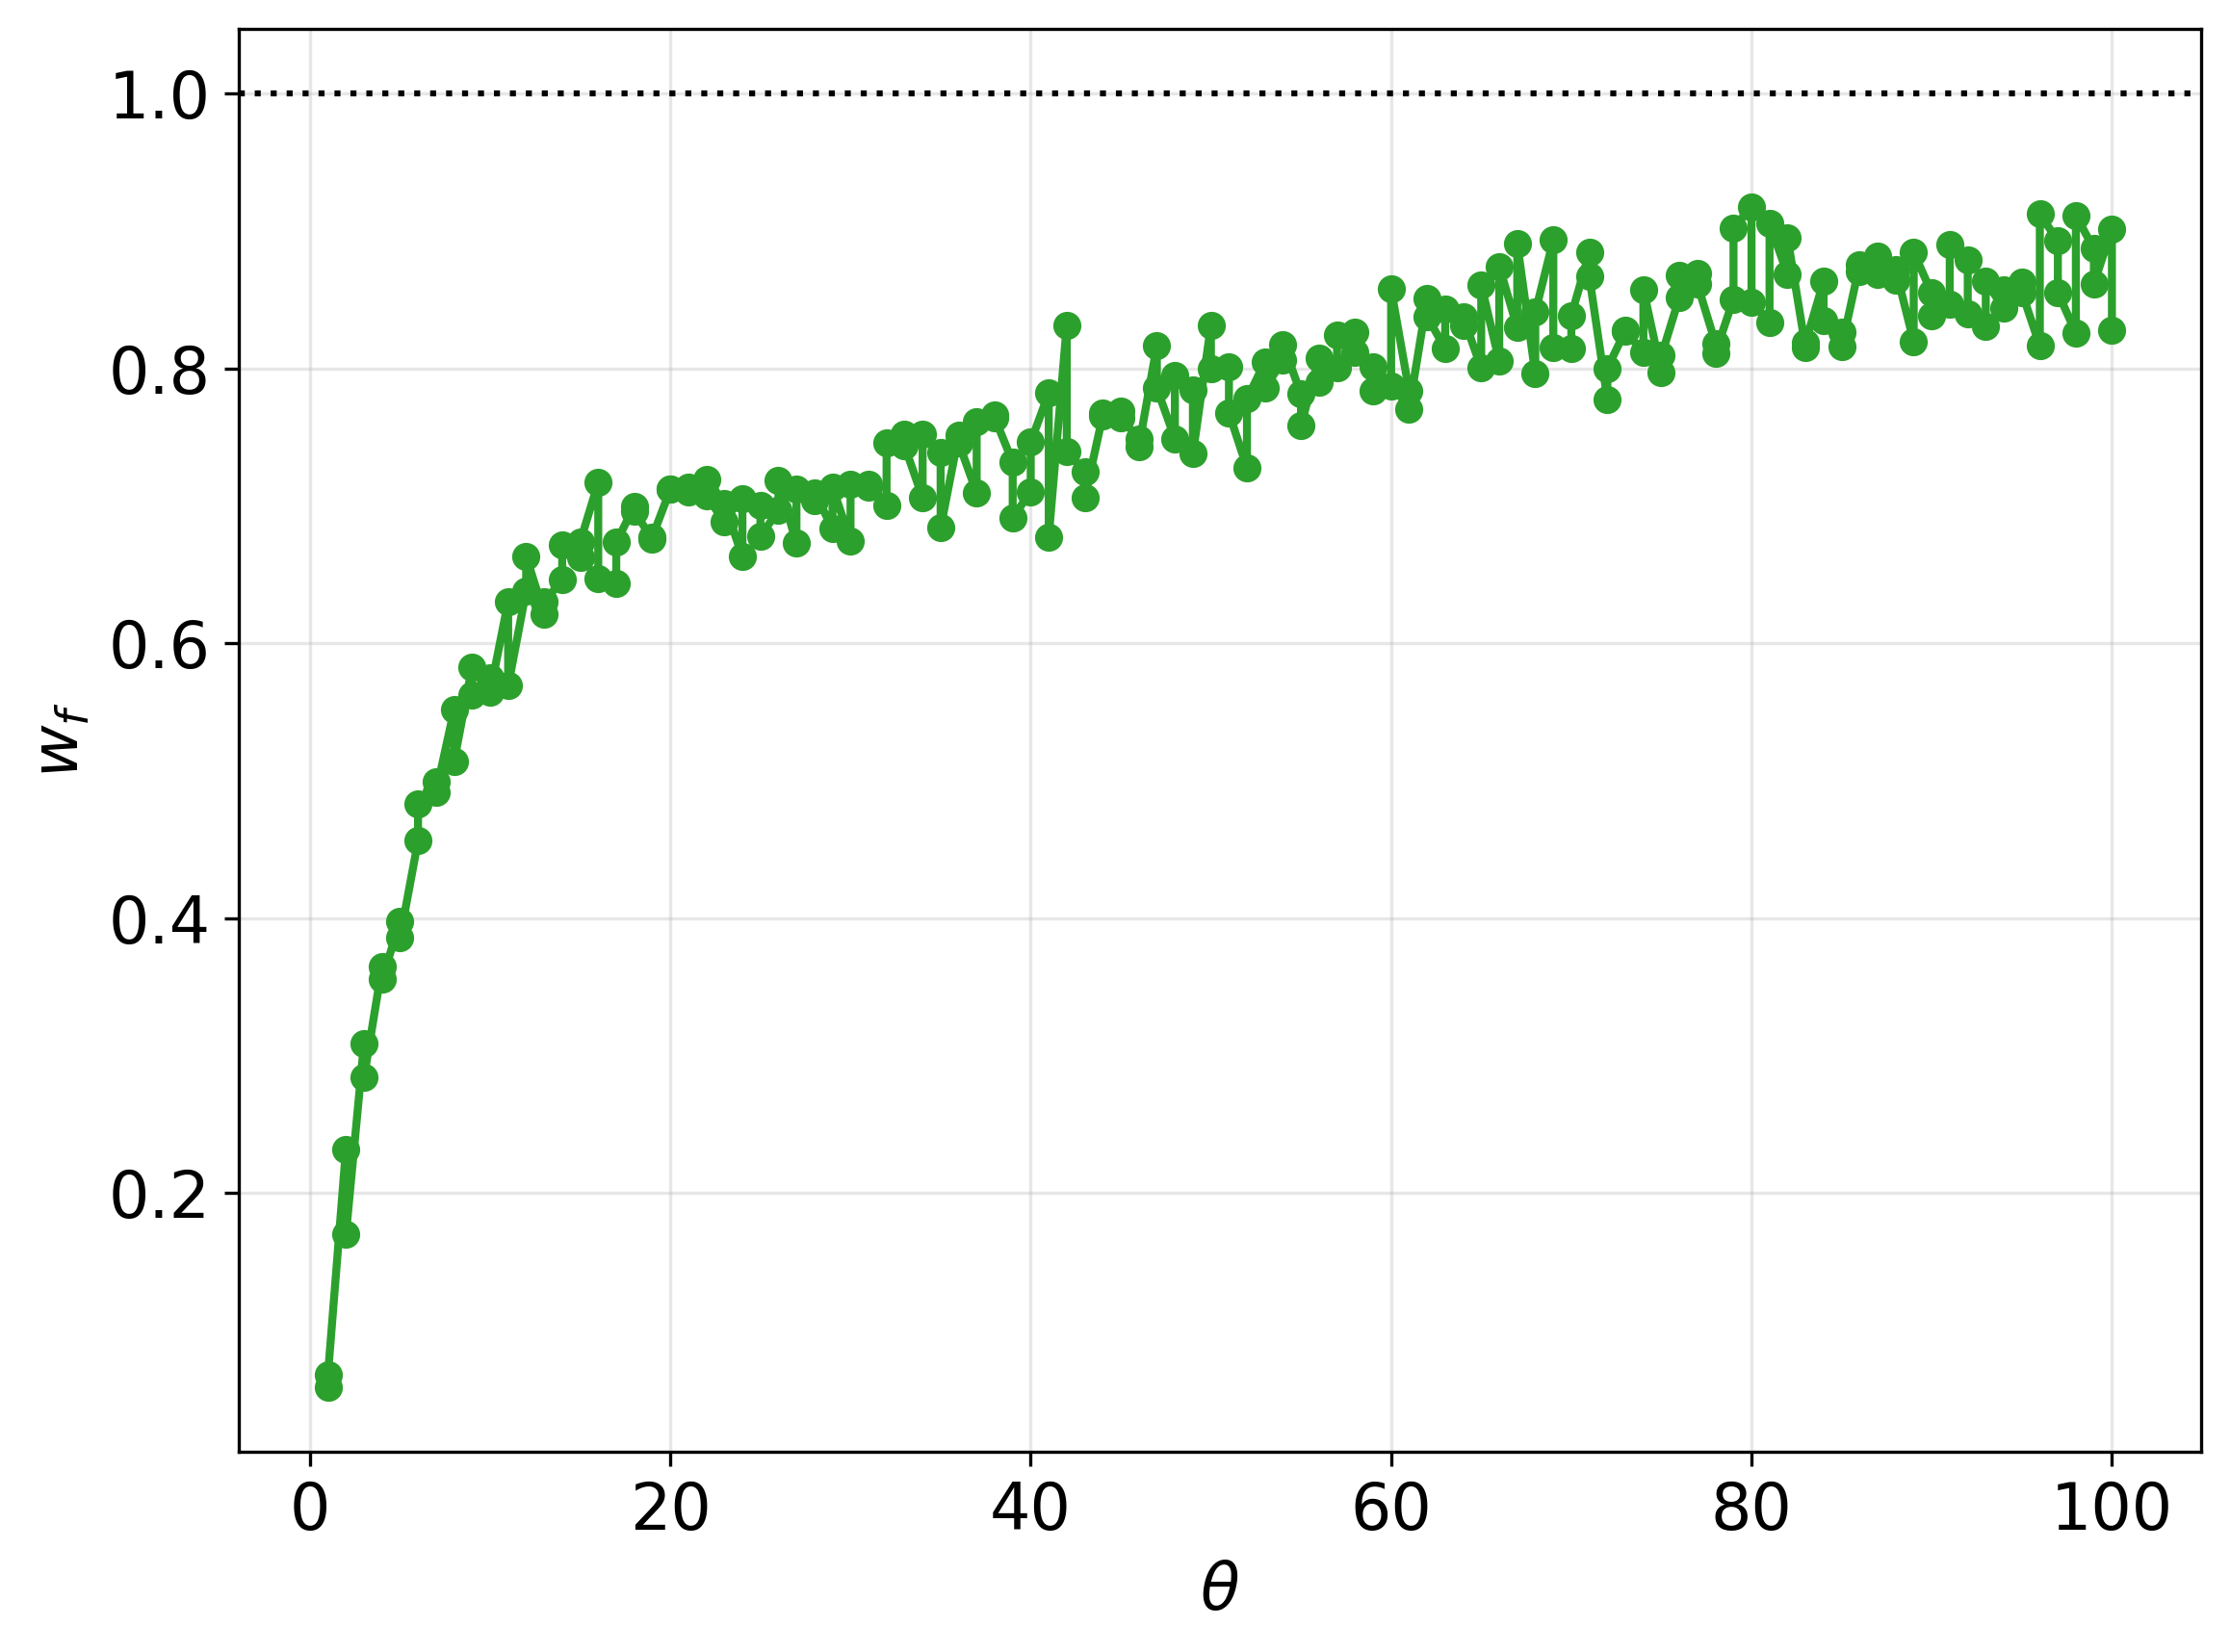

In [7]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt

from nucleo.io.reading import getting_main_file_with_verifications

plt.rcParams["font.size"] = 16

# ── 2.2 : Getting datas ──────────────────────────────────────────────────────

# Root
root = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "NUCLEO__PSMN__2026-06-19"

# Reading
path_datas = root / "ncl_output.parquet"
df_all = pl.read_parquet(path_datas)

# Loading + Filtering
df_secured = getting_main_file_with_verifications(df_all)

# Ordering
df_sorted = df_secured.sort(
        by=["s", "land", "bpmin", "l"],
        descending=[False, False, False, False]
    )
# print(df_sorted)

# ── 2.3 : Reading Scenarios ──────────────────────────────────────────────────

# Reading
path_scenario = root / "scenarios.json"
df_all_scen = pl.read_json(path_scenario)

# Ordering
df_all_scen_ordered = df_all_scen.sort(
        by=["s", "land", "bpmin", "l"],
        descending=[False, False, False, False]
    )
# print(df_all_scen_ordered)
print(df_all_scen)

# ── Sélection du scénario ─────────────────────────────────────────────────────
df_scen_work = df_all_scen[9]
print("Working on :\n", df_scen_work)

df_work = df_sorted.filter(
    (df_sorted["land"] == df_scen_work["land"]) &
    (df_sorted["s"] == df_scen_work["s"]) &
    (df_sorted["l"] == df_scen_work["l"]) &
    (df_sorted["bpmin"] == df_scen_work["bpmin"])
)
# print(df_work)

mus = np.unique(df_work["mu"].to_numpy())
thetas = np.unique(df_work["theta"].to_numpy())
# print(mus, thetas)

# ── wf vs theta (coupe à mu fixé) ────────────────────────────────────────────
mus_cut = 160

df_all_plot = df_work.filter(
    pl.col("mu") == mus_cut
)

thetas = np.unique(df_all_plot["theta"].to_numpy())

# ── Couleur (cohérence sémantique : vert dédié à cette quantité wf) ─────────
color_list = ["tab:green"]
color = color_list[0]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

df_mu = (
    df_all_plot
    .filter(pl.col("mu") == mus_cut)
    .sort("theta")
)

theta = df_mu["theta"].to_numpy()
wf = df_mu["wf"].to_numpy()

ax.plot(
    theta, wf,
    marker="o",
    lw=2,
    color=color
)

ax.axhline(y=1, c="k", ls=":")

# ── Styling ──────────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$w_f$")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 3.D : Heatmap normalisée ($v_f$, norm\_th) pour une configuration donnée

/tmp/ipykernel_19533/3332841180.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


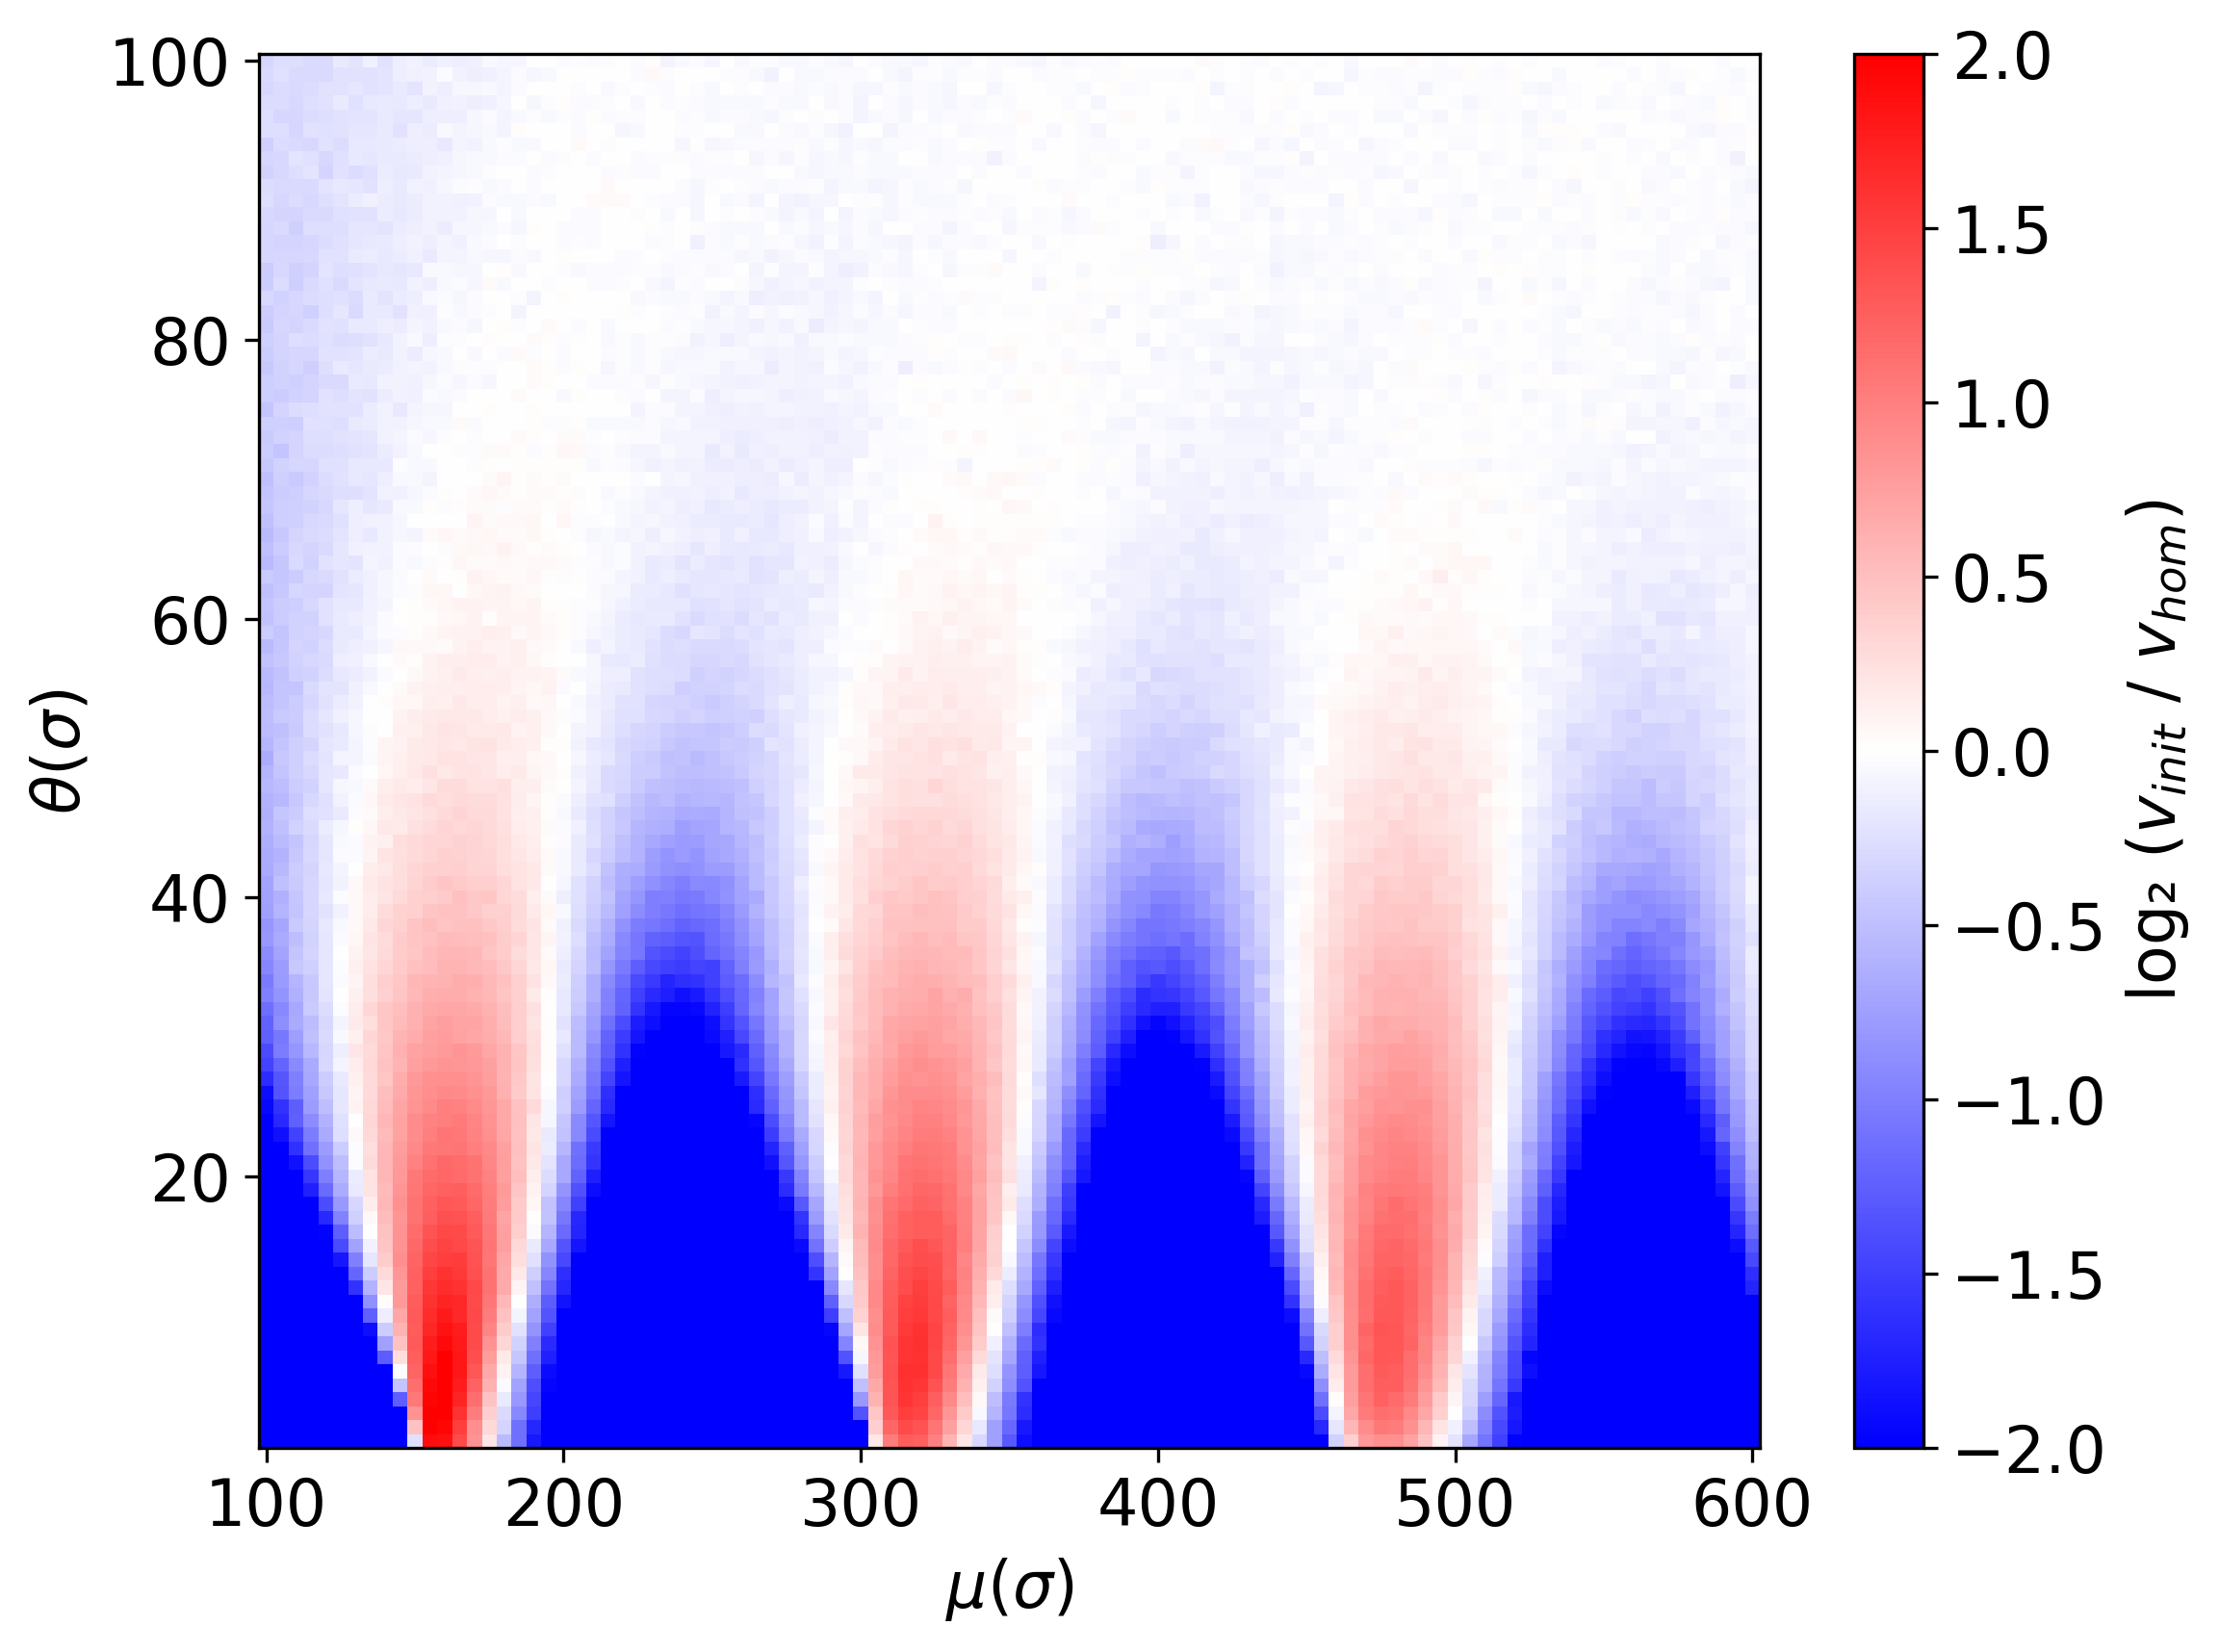

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.plots_2D import plot_one_heatmap_from_df

plt.rcParams["font.size"] = 16

# ── Root (même source que 3.C) ───────────────────────────────────────────────
root = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "NUCLEO__PSMN__2026-06-19"

# ── Data ──────────────────────────────────────────────────────────────────────
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")
points = [(160, 20), (160, 60), (240, 20), (240, 60)]

# ── Couleurs (une couleur par point sélectionné, même style que 2.C) ────────
cmap = cm.get_cmap("plasma")
color_positions = np.linspace(0.1, 0.9, len(points))
color_list = [cmap(pos) for pos in color_positions]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=9,        # équivalent du `key` de l'ancien dict (premier idx = 0)
    speed_col="vf",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=True,
    dashed_line=False,
    title=False,
)

# Points sélectionnés (décommenter pour les afficher sur la heatmap)
# for i, (mu_pt, theta_pt) in enumerate(points):
#     ax.scatter(
#         mu_pt,
#         theta_pt,
#         color=color_list[i],
#         s=100,              # taille du point
#         edgecolor="black",  # contour du point
#         zorder=10           # pour être au-dessus de la heatmap
#     )

plt.tight_layout()
plt.show()


# 3.E : Vue du paysage ($l_{view}$) avec zoom

/tmp/ipykernel_19209/3053595507.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


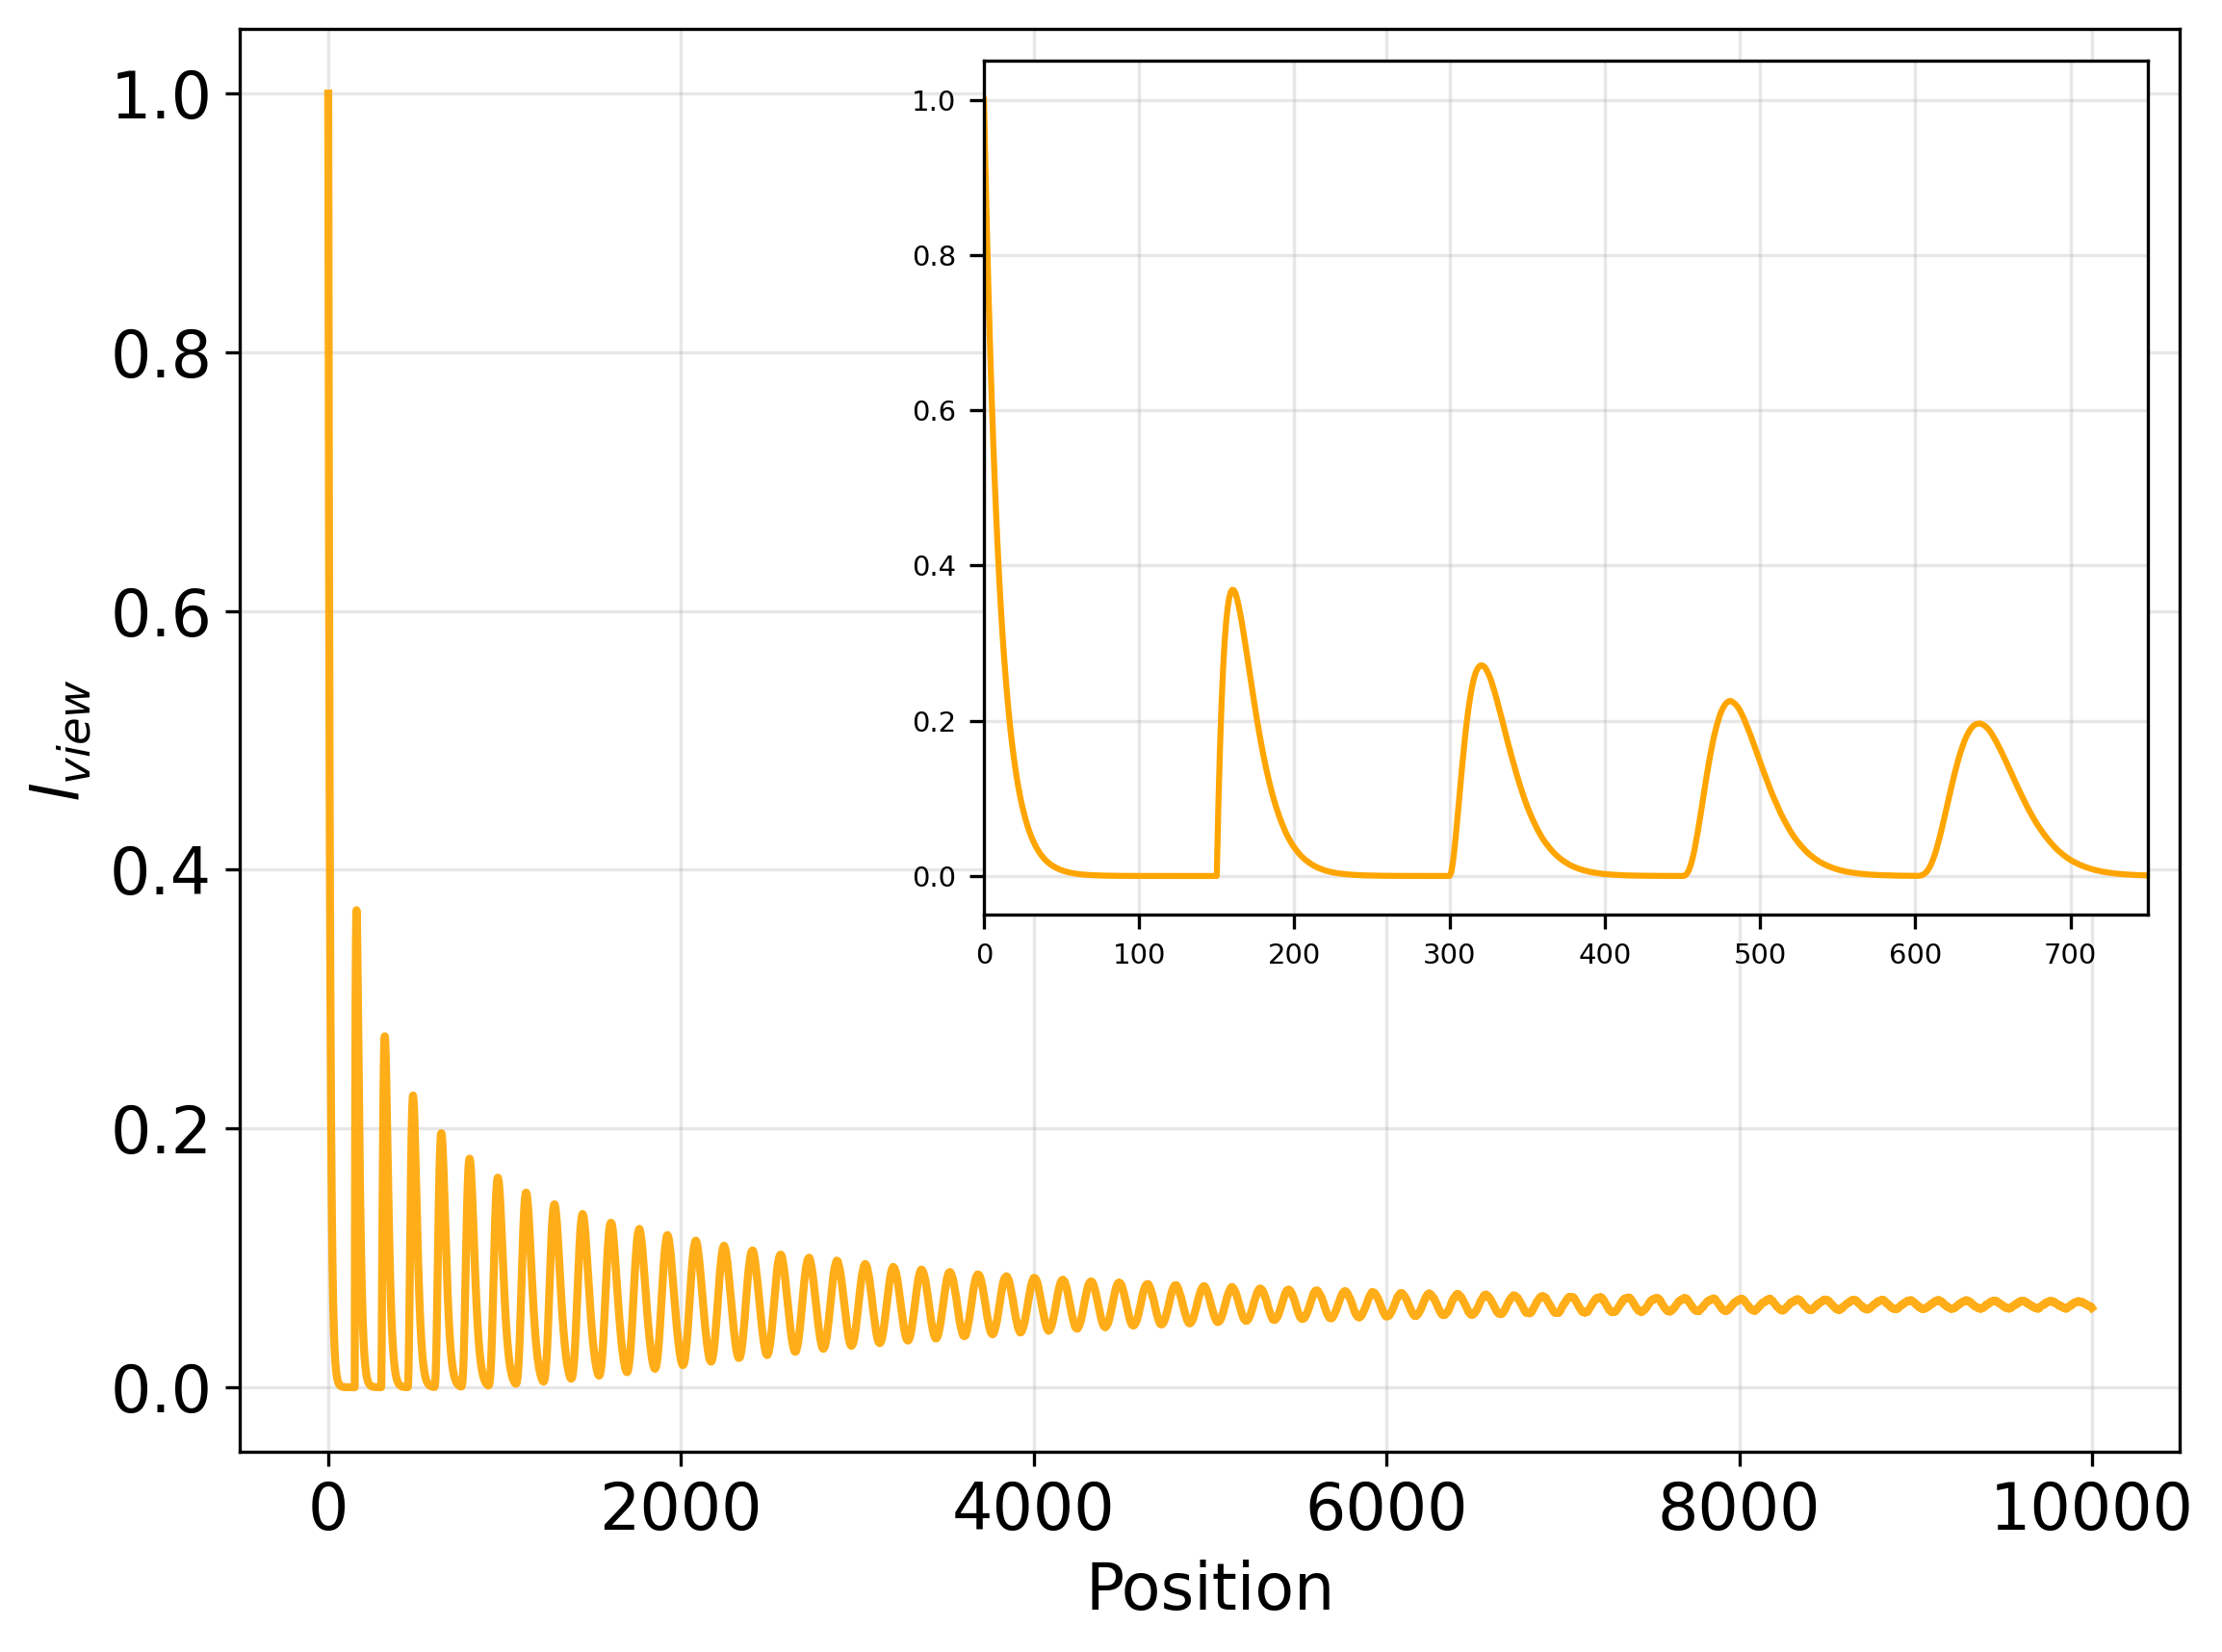

In [5]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams["font.size"] = 16

# ── Load files (même source que 3.A / 3.B) ──────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig3__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

# ── Couleur (orange dédié à l_view) ──────────────────────────────────────────
color_list = ["orange"]
color = color_list[0]

# ── Figure ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6), dpi=300)
ax = plt.gca()

# Choix du theta à afficher
theta_val = np.unique(df_all["theta"].to_numpy())[0]  # ou une valeur précise

df_theta = df_all.filter(pl.col("theta") == theta_val)

l_view = df_theta["l_view"][0]
x = np.arange(len(l_view))

# Tracé principal
ax.plot(
    x,
    l_view,
    lw=2,
    alpha=0.9,
    label=rf"$\theta={theta_val}$",
    c=color
)

# ── Inset zoom ───────────────────────────────────────────────────────────────
axins = inset_axes(ax, width="60%", height="60%", loc="upper right")

n_zoom = min(750, len(l_view))

axins.plot(
    x[:n_zoom],
    l_view[:n_zoom],
    lw=1.5,
    c=color
)

axins.set_xlim(0, n_zoom)
axins.grid(True, alpha=0.3)
axins.tick_params(axis='both', labelsize=7)

# ── Légendes ─────────────────────────────────────────────────────────────────
ax.set_xlabel("Position")
ax.set_ylabel(r"$l_{view}$")
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


# FIGURE 3

/tmp/ipykernel_9867/228897585.py:209: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = cm.get_cmap("viridis")


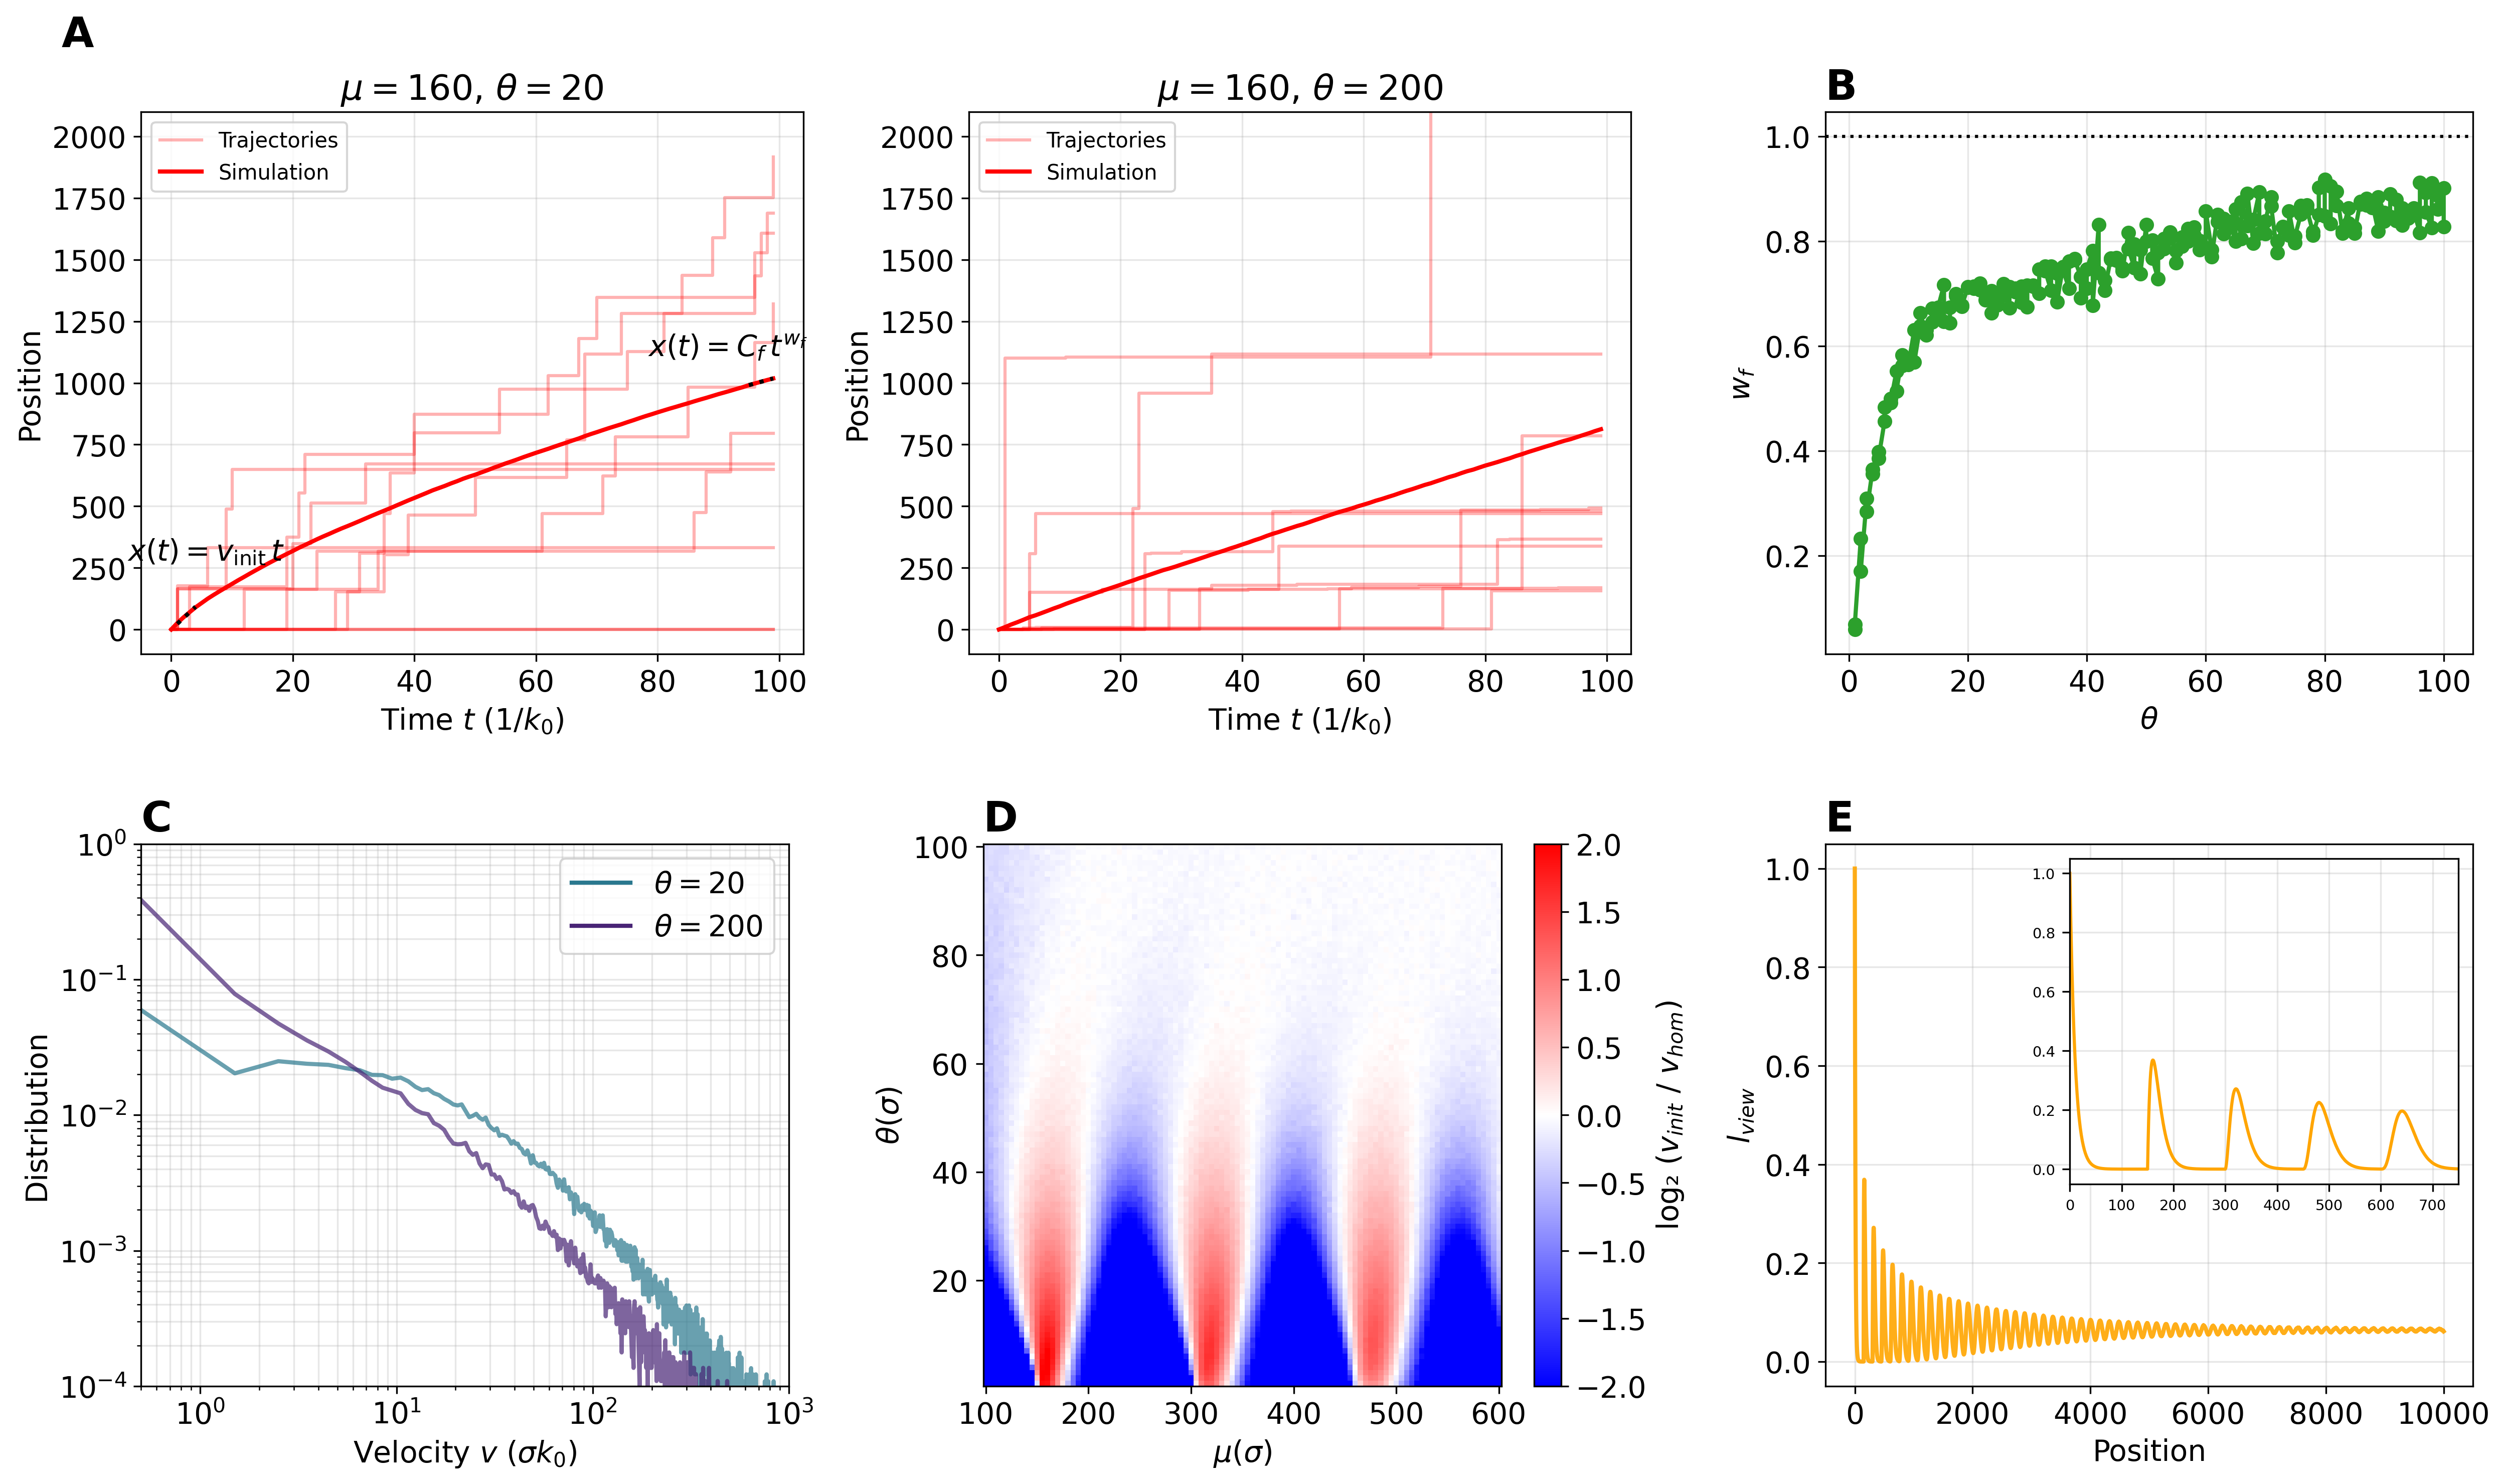

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 3 FINALE COMPOSITE
# ──────────────────────────────────────────────────────────────────────────────
# Cellule autonome : recharge elle-même chaque source de données sous un nom
# dédié (df_traj_*, df_scen_*, heatmaps_df) pour éviter toute collision entre
# les deux jeux de données utilisés dans ce notebook (FIGURES__PC__... pour
# les trajectoires/distributions/l_view, NUCLEO__PSMN__... pour wf/heatmap).
#
# Correspondance lettres (figure) <-> sections (notebook) :
#   A = 3.A (trajectoires)         B = 3.C (wf vs theta)
#   C = 3.B (distribution vitesse) D = 3.D (heatmap)
#   E = 3.E (l_view + zoom)

from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from nucleo.io.reading import getting_main_file_with_verifications
from nucleo.io.plots_2D import plot_one_heatmap_from_df

plt.rcParams["font.size"] = 14

# ═══════════════════════════════════════════════════════════════════════════
# CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════════════════════════

# --- Source 1 : trajectoires / distributions / l_view (landscape random) ----
root_traj = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/"
    "FIGURES__PC__2026-06-18/nucleo__fig3__0"
)
paths_traj = (
    sorted(str(p) for p in root_traj.glob("*/**/*.parquet"))
    or sorted(str(p) for p in root_traj.glob("*/*.parquet"))
)

df_traj_all = (
    pl.scan_parquet(paths_traj)
    .collect()
    .sort(by=["algo", "fact", "mode", "land", "s", "l", "alphac", "alphar"])
)

df_traj_random = df_traj_all.filter(pl.col("land") == "random")  # panel A

# --- Source 2 : scénarios (wf vs theta + heatmap) ----------------------------
root_scen = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "NUCLEO__PSMN__2026-06-19"

df_scen_raw = pl.read_parquet(root_scen / "ncl_output.parquet")
df_scen_secured = getting_main_file_with_verifications(df_scen_raw)
df_scen_sorted = df_scen_secured.sort(
    by=["s", "land", "bpmin", "l"],
    descending=[False, False, False, False],
)

df_scen_all = pl.read_json(root_scen / "scenarios.json")
df_scen_work = df_scen_all[9]

df_work_B = df_scen_sorted.filter(
    (df_scen_sorted["land"] == df_scen_work["land"]) &
    (df_scen_sorted["s"] == df_scen_work["s"]) &
    (df_scen_sorted["l"] == df_scen_work["l"]) &
    (df_scen_sorted["bpmin"] == df_scen_work["bpmin"])
)

heatmaps_df = pl.read_parquet(root_scen / "ncl_heatmaps.parquet")  # panel D

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE
# ═══════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 11), dpi=300)

gs = fig.add_gridspec(
    nrows=2, ncols=3,
    height_ratios=[1.0, 1.0],
    hspace=0.35, wspace=0.3
)

# ═══════════════════════════════════════════════════════════════════════════
# Row 1 : A (2 sous-panels) + B
# ═══════════════════════════════════════════════════════════════════════════
gs_A = gs[0, 0:2].subgridspec(nrows=1, ncols=2, wspace=0.25)
ax_A1 = fig.add_subplot(gs_A[0, 0])
ax_A2 = fig.add_subplot(gs_A[0, 1])
ax_B = fig.add_subplot(gs[0, 2])

# --- A : trajectoires (logique de 3.A) ---
target_pairs_A = [(160, 20), (160, 200)]
fits_A = [True, False]          # fit affiché seulement sur le 1er sous-panel
n_fit_init, n_fit_final = 5, 5
axes_A = [ax_A1, ax_A2]
color_A = "red"

for ax_A, (mu_val, theta_val), do_fit in zip(axes_A, target_pairs_A, fits_A):

    df_theta = df_traj_random.filter(
        (pl.col("mu") == mu_val) &
        (pl.col("theta") == theta_val)
    )

    trajs = df_theta["results"][0]
    mean_traj = np.asarray(df_theta["results_mean"][0])
    times = np.asarray(df_theta["times"][0])
    mu = df_theta["mu"][0]

    n_traj = min(10, len(trajs))
    for i in range(n_traj):
        ax_A.plot(
            trajs[i], drawstyle="steps-post",
            color=color_A, alpha=0.3,
            label="Trajectories" if i == 0 else None,
        )

    ax_A.plot(times, mean_traj, color=color_A, lw=2, label="Simulation")

    if do_fit:

        # Fit initial : x(t) = v_init * t
        if len(times) >= n_fit_init:
            t_init = times[:n_fit_init]
            x_init = mean_traj[:n_fit_init]
            mask = t_init > 0

            if np.sum(mask) >= 2:
                t_fit = t_init[mask]
                x_fit = x_init[mask]
                v_init = np.sum(t_fit * x_fit) / np.sum(t_fit ** 2)
                x_init_fit = v_init * t_fit

                ax_A.plot(t_fit, x_init_fit, color="black", ls=":", lw=2)

                idx_txt = len(t_fit) // 2
                x_offset = 0.025 * (ax_A.get_xlim()[1] - ax_A.get_xlim()[0])
                y_offset = 0.10 * (ax_A.get_ylim()[1] - ax_A.get_ylim()[0])

                ax_A.text(
                    t_fit[idx_txt] + x_offset, x_init_fit[idx_txt] + y_offset,
                    r"$x(t)=v_{\rm init}\,t$",
                    color="black", fontsize=plt.rcParams["font.size"], ha="center",
                )

        # Fit final : x(t) = C_f * t^{w_f}
        if len(times) >= n_fit_final:
            t_end = times[-n_fit_final:]
            x_end = mean_traj[-n_fit_final:]
            mask = (t_end > 0) & (x_end > 0)

            if np.sum(mask) >= 2:
                log_t = np.log(t_end[mask])
                log_x = np.log(x_end[mask])
                wf, log_Cf = np.polyfit(log_t, log_x, 1)
                Cf = np.exp(log_Cf)
                x_end_fit = Cf * t_end ** wf

                ax_A.plot(t_end, x_end_fit, color="black", ls=":", lw=2)

                idx_txt = len(t_end) // 2
                x_offset = 0.05 * (ax_A.get_xlim()[1] - ax_A.get_xlim()[0])
                y_offset = 0.05 * (ax_A.get_ylim()[1] - ax_A.get_ylim()[0])

                ax_A.text(
                    t_end[idx_txt] - x_offset, x_end_fit[idx_txt] + y_offset,
                    r"$x(t)=C_f\,t^{w_f}$",
                    color="black", fontsize=plt.rcParams["font.size"], ha="center",
                )

    ax_A.set_ylim([-100, 2100])
    ax_A.set_title(rf"$\mu={mu}$, $\theta={theta_val}$")
    ax_A.set_xlabel(r"Time $t$ ($1/k_0$)")
    ax_A.set_ylabel("Position")
    ax_A.grid(alpha=0.3)
    ax_A.legend(fontsize=10)

ax_A1.text(-0.12, 1.12, "A", transform=ax_A1.transAxes,
           fontweight="bold", fontsize=20)

# --- B : wf vs theta, coupe à mu fixé (logique de 3.C) ---
mus_cut_B = 160

df_all_plot_B = df_work_B.filter(pl.col("mu") == mus_cut_B)
df_mu_B = df_all_plot_B.filter(pl.col("mu") == mus_cut_B).sort("theta")

theta_B = df_mu_B["theta"].to_numpy()
wf_B = df_mu_B["wf"].to_numpy()

ax_B.plot(theta_B, wf_B, marker="o", lw=2, color="tab:green")
ax_B.axhline(y=1, c="k", ls=":")

ax_B.set_xlabel(r"$\theta$")
ax_B.set_ylabel(r"$w_f$")
ax_B.grid(True, alpha=0.3)
ax_B.set_title("B", loc="left", fontweight="bold", fontsize=20)

# ═══════════════════════════════════════════════════════════════════════════
# Row 2 : C, D, E
# ═══════════════════════════════════════════════════════════════════════════
ax_C = fig.add_subplot(gs[1, 0])
ax_D = fig.add_subplot(gs[1, 1])
ax_E = fig.add_subplot(gs[1, 2])

# --- C : distribution des vitesses, theta=20 / theta=200 (logique de 3.B) ---
thetas_C = np.array([20, 200])

cmap_C = cm.get_cmap("viridis")
color_positions_C = np.linspace(0.1, 0.4, len(thetas_C))
color_list_C = [cmap_C(pos) for pos in color_positions_C]
color_list_C.reverse()

for idx, theta_val in enumerate(thetas_C):
    df_theta = df_traj_all.filter(pl.col("theta") == theta_val)
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()

    ax_C.plot(
        vi_points, vi_distrib,
        color=color_list_C[idx], ls="-", lw=2, alpha=0.70,
    )

theta_labels_C = [r"$\theta={}$".format(t) for t in thetas_C]
color_legend_C = [
    Line2D([0], [0], color=color_list_C[i], lw=2, label=theta_labels_C[i])
    for i in range(len(thetas_C))
]
ax_C.legend(handles=color_legend_C, loc="upper right", frameon=True)

ax_C.set_xlabel(r'Velocity $v$ ($\sigma k_0$)')
ax_C.set_ylabel("Distribution")
ax_C.set_xlim([5e-1, 1e3])
ax_C.set_ylim([1e-4, 1e0])
ax_C.set_xscale("log")
ax_C.set_yscale("log")
ax_C.grid(True, alpha=0.3, which="both")
ax_C.set_title("C", loc="left", fontweight="bold", fontsize=20)

# --- D : heatmap normalisée (vf, norm_th) (logique de 3.D) ---
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=9,
    speed_col="vf",
    ax=ax_D,
    type_of_data="norm_th",
    plot_log2=True,
    dashed_line=False,
    title=False,
)
ax_D.set_title("D", loc="left", fontweight="bold", fontsize=20)

# --- E : vue du paysage l_view + zoom (logique de 3.E) ---
color_E = "orange"
theta_val_E = np.unique(df_traj_all["theta"].to_numpy())[0]

df_theta_E = df_traj_all.filter(pl.col("theta") == theta_val_E)
l_view = df_theta_E["l_view"][0]
x_E = np.arange(len(l_view))

ax_E.plot(x_E, l_view, lw=2, alpha=0.9, c=color_E)

axins_E = inset_axes(ax_E, width="60%", height="60%", loc="upper right")
n_zoom = min(750, len(l_view))
axins_E.plot(x_E[:n_zoom], l_view[:n_zoom], lw=1.5, c=color_E)
axins_E.set_xlim(0, n_zoom)
axins_E.grid(True, alpha=0.3)
axins_E.tick_params(axis="both", labelsize=7)

ax_E.set_xlabel("Position")
ax_E.set_ylabel(r"$l_{view}$")
ax_E.grid(True, alpha=0.3, which="both")
ax_E.set_title("E", loc="left", fontweight="bold", fontsize=20)

plt.savefig("fig3_final.png", bbox_inches="tight", dpi=300)
plt.show()


# .